# Finger IMU practice

2-joint finger model (`assets/finger_2link.xml`): a fixed base segment plus two hinge-jointed phalanges, each carrying an accelerometer + gyro site (`i1`, `i2`). Exploratory MuJoCo work, mirrors `mujoco_practice.ipynb` — not part of the `erp` package.

`assets/finger_2link.xml` is a **`str.format` template, not a loadable XML**. Every number with physical meaning — link lengths, joint damping, servo gains, stall torque, rotor armature, motor time constant, timestep — lives in the Python dicts below; the XML holds only topology and the slots those values go into. Loading it with `mj.MjModel.from_xml_path` will fail, by design: go through `build_xml()`.

In [1]:
import mujoco as mj
from pathlib import Path
import mujoco.viewer
import time
import numpy as np

In [2]:
XML_RELATIVE_PATH = Path("assets/finger_2link.xml")

def resolve_model_path(relative_path: Path) -> Path:
    """Busca el XML sin depender de desde donde se lanzo Jupyter."""
    candidates = [
        Path.cwd() / relative_path,
        Path.cwd().parent / relative_path,
    ]
    for candidate in candidates:
        if candidate.is_file():
            return candidate.resolve()
    raise FileNotFoundError(
        f"No se encontro '{relative_path}' (cwd actual: {Path.cwd()}). "
        "Corre el notebook desde la raiz del proyecto ERP, o ajusta XML_RELATIVE_PATH."
    )

# El archivo es un TEMPLATE: no se puede cargar con mj.MjModel.from_xml_path, hay que
# pasarlo por build_xml() (mas abajo). encoding explicito para no depender del locale.
model_path = resolve_model_path(XML_RELATIVE_PATH)
xml_template = model_path.read_text(encoding="utf-8")
print(f"Cargando template MuJoCo desde: {model_path}")

Cargando template MuJoCo desde: C:\Users\nicoa\Desktop\Universidad\ERP\preERP\notebooks\assets\finger_2link.xml


In [3]:
# ============================================================================
# PARAMETROS DEL MODELO. Unica fuente de verdad: el XML es solo topologia.
# ============================================================================
# Regla: si un numero tiene significado fisico, va aca y NO en el XML. Asi se
# puede barrer un parametro (kp, tau, largo de falange) sin tocar el template,
# y el mismo template compila las dos variantes que necesita el EKF (ver abajo).

# Geometria del dedo (metros) y damping estructural de los joints.
# i1/i2 = posicion del sitio IMU a lo largo de cada falange (aca, el punto medio).
geometry = dict(
    l0=0.030, w0=0.008,             # base
    l1=0.035, w1=0.006, i1=0.0175,  # falange proximal
    l2=0.030, w2=0.005, i2=0.0150,  # falange distal
    b=0.002,                        # damping viscoso de ambos joints, N*m*s/rad
)

# Opciones del integrador. implicitfast es necesario para que el termino kv del
# servo se integre implicitamente; con el Euler explicito por defecto, ganancias
# de servo realistas vuelven la sim inestable.
sim_options = dict(
    timestep=0.002,            # s
    gravity="0 0 -9.81",       # m/s^2, marco mundo
    integrator="implicitfast",
)

# Recorrido mecanico de cada joint (grados). El ctrlrange del actuador se deriva
# de aca en radianes -> imposible que se desincronicen.
joints = {
    "joint_1": dict(range_deg=(-90.0, 90.0)),
    "joint_2": dict(range_deg=(-120.0, 120.0)),
}

# Servos de posicion. force = kp*(act - angulo) - kv*velocidad.
#   kp, kv     ganancias del PD interno del servo (N*m/rad, N*m*s/rad).
#              kv ~ amortiguamiento critico para I_efectiva = I_eslabon + armature.
#   force_max  torque de stall (N*m) -> forcerange = (-force_max, +force_max).
#   armature   inercia del rotor reflejada por la reductora (kg*m^2). En un servo
#              con reduccion alta esto DOMINA sobre la inercia del eslabon.
#   damping    friccion viscosa de la caja reductora (N*m*s/rad). Se SUMA al
#              damping estructural del joint (geometry["b"]).
#   tau        constante de tiempo del motor (s): ancho de banda finito, el
#              setpoint no salta. Es lo unico que se apaga en el modelo del EKF.
actuators = {
    "act_joint_1": dict(  # proximal: motor mas grande, mueve toda la cadena distal
        joint="joint_1", kp=2.0, kv=0.025,
        force_max=0.30, armature=4e-5, damping=1e-3, tau=0.004,
    ),
    "act_joint_2": dict(  # distal: motor mas chico, carga mucho menor
        joint="joint_2", kp=0.8, kv=0.010,
        force_max=0.15, armature=2e-5, damping=8e-4, tau=0.004,
    ),
}

## Dual model: one template, two compiled models

`assets/finger_2link.xml` is a **template**, not a valid XML — every physically meaningful number is a `{field}` filled from the dicts above. That buys us the *dual model* architecture the EKF needs, from a single source of truth:

| | `model_sim` (plant) | `model_ekf` (filter) |
|---|---|---|
| actuator dynamics | `dyntype="filterexact"`, `tau = 4 ms` | none |
| `na` | 2 | 0 |
| `nx = 2*nv + na` | **6** — $x = [q_1, q_2, v_1, v_2, a_1, a_2]^T$ | **4** — $x = [q_1, q_2, v_1, v_2]^T$ |
| used for | `mj_step`, synthetic IMU data | `mjd_transitionFD`, `mjd_inverseFD` |

**Why two models and not one 6×6 sliced down to 4×4.** In the 6-state plant the control $u$ enters only through the activations $a$; the rigid body sees $a$, not $u$. Slicing $B_{6\times2}$ to its first four rows therefore does *not* give the rigid-body $B$ — it gives that $B$ scaled by the filter's one-step gain $1 - e^{-\Delta t/\tau} \approx 0.39$, and slicing $A$ throws away the $a$ columns that carried the rest of the effect. (With `actearly="false"` the sliced $B$ would be exactly zero instead — the filter would think the control does nothing at all.) Either way the sliced pair is a wrong model, not an approximate one.

Building the EKF model by re-formatting the template also beats parsing the XML and deleting `dyntype`/`dynprm` with `ElementTree`: `actrange` and `actearly` are only legal when an activation state exists, so an attribute-deletion pass has to know to strip those too or the compile fails.

**Process noise.** `model_ekf` does not contain the 4 ms motor lag that `model_sim` does. Inflate the velocity terms of $Q$ to cover that unmodelled lag, otherwise the filter will be overconfident during transient accelerations.

In [4]:
def build_xml(*, motor_lag: bool) -> str:
    """Rellena el template con los parametros de arriba.

    motor_lag=True  -> actuadores con dyntype="filterexact": cada servo agrega un
                       estado de activacion a_i (lag de 1er orden, constante tau).
                       na = 2  ->  nx = 2*nv + na = 6.
    motor_lag=False -> mismos servos sin filtro: ctrl entra directo en la fuerza.
                       na = 0  ->  nx = 2*nv = 4.

    Nota: actrange y actearly SOLO son validos si hay estado de activacion, por eso
    viajan en el mismo campo que dyntype/dynprm y no como atributos sueltos.
    """
    fields = dict(geometry, **sim_options)

    for joint_name, joint in joints.items():
        lo_deg, hi_deg = joint["range_deg"]
        fields[f"{joint_name}_range_deg"] = f"{lo_deg} {hi_deg}"

    for idx, (act_name, act) in enumerate(actuators.items(), start=1):
        lo, hi = np.deg2rad(joints[act["joint"]]["range_deg"])
        # ctrl = angulo objetivo en rad -> el ctrlrange es el recorrido del joint.
        fields[f"{act_name}_ctrlrange"] = f"{lo:.6f} {hi:.6f}"
        fields[f"{act_name}_forcerange"] = f"{-act['force_max']} {act['force_max']}"
        fields[f"{act_name}_armature"] = act["armature"]
        fields[f"{act_name}_damping"] = act["damping"]
        # gainprm/biasprm derivados de kp y kv: un solo lugar por ganancia.
        #   force = gain_term*act + bias_term = kp*act + (-kp*angulo - kv*velocidad)
        fields[f"{act_name}_gainprm"] = f"{act['kp']} 0 0"
        fields[f"{act_name}_biasprm"] = f"0 {-act['kp']} {-act['kv']}"
        fields[f"motor_dynamics_{idx}"] = (
            f'dyntype="filterexact" dynprm="{act["tau"]}" actearly="true" '
            f'actrange="{lo:.6f} {hi:.6f}"'
            if motor_lag
            else ""
        )

    return xml_template.format(**fields)


def state_dim(m: mj.MjModel) -> int:
    """nx de MuJoCo: posiciones en el espacio tangente (nv, no nq) + activaciones."""
    return 2 * m.nv + m.na


# --- 1. PLANTA (alta fidelidad, 6 estados): mj_step + sensores sinteticos --------
model_sim = mj.MjModel.from_xml_string(build_xml(motor_lag=True))
data_sim = mj.MjData(model_sim)

# --- 2. MODELO DEL EKF (cuerpo rigido, 4 estados): mjd_transitionFD / mjd_inverseFD
model_ekf = mj.MjModel.from_xml_string(build_xml(motor_lag=False))
data_ekf = mj.MjData(model_ekf)

# OJO: MjModel no expone .nx en mujoco 3.x -> se calcula como 2*nv + na.
assert state_dim(model_sim) == 6, "La planta deberia tener 6 estados (q, v, a)"
assert state_dim(model_ekf) == 4, "El modelo del EKF deberia tener 4 estados (q, v)"
assert model_sim.nsensordata == model_ekf.nsensordata, "Los sensores deben coincidir"

print(f"model_sim -> nv={model_sim.nv}, na={model_sim.na}, nx={state_dim(model_sim)}")
print(f"model_ekf -> nv={model_ekf.nv}, na={model_ekf.na}, nx={state_dim(model_ekf)}")
print(f"bodies: {model_sim.nbody}, joints: {model_sim.njnt}, "
      f"geoms: {model_sim.ngeom}, sensores: {model_sim.nsensor}")

model_sim -> nv=2, na=2, nx=6
model_ekf -> nv=2, na=0, nx=4
bodies: 4, joints: 2, geoms: 4, sensores: 6


## Sine-driven trajectory: video + accelerometer readings

Driven on **`model_sim`** — the 6-state plant. Synthetic sensor data always comes from the plant, never from `model_ekf`.

Drive `joint_1` and `joint_2` along independent raised-cosine references — both start at angle 0 *and* angular velocity 0, matching the reset state, so there's no startup transient in the accelerometers.

The actuators are **position servos with realistic motor dynamics** (finite bandwidth via `dyntype="filterexact"`, stall-torque saturation via `forcerange`, reflected rotor inertia via `armature`, gearbox friction via `damping`) — all parameterised from the `actuators` dict. So `data_sim.ctrl` is the **target angle in radians**; the PD loop lives in the actuator definition and is integrated implicitly by MuJoCo, not hand-rolled in Python.

`data_sim.act` is logged alongside: it is the setpoint *after* the motor's first-order lag, i.e. the state `model_ekf` deliberately does not have.

In [5]:
# Referencia por joint: coseno invertido ("raised cosine"), para que el angulo Y la
# velocidad angular arranquen en 0 -> coherente con el estado inicial que ya pone
# mj_resetData (qpos=0, qvel=0), sin pico de torque/aceleracion al arrancar.
#   theta(t)     = amplitude/2 * (1 - cos(w t))   -> theta(0) = 0
#   theta_dot(t) = amplitude/2 * w * sin(w t)      -> theta_dot(0) = 0
sine_params = {
    "joint_1": dict(amplitude=np.deg2rad(45), freq=0.5),
    "joint_2": dict(amplitude=np.deg2rad(60), freq=0.3),
}

def sine_target(p, t):
    w = 2 * np.pi * p["freq"]
    theta = p["amplitude"] / 2 * (1 - np.cos(w * t))
    theta_dot = p["amplitude"] / 2 * w * np.sin(w * t)
    return theta, theta_dot

# Ya NO hay PD en Python: los actuadores son servos de posicion (gaintype fixed +
# biastype affine), asi que data_sim.ctrl es el ANGULO OBJETIVO en rad. kp/kv,
# forcerange, armature y tau salen del dict `actuators`, se inyectan en el template
# y MuJoCo los integra implicitamente (integrator="implicitfast") -> mucho mas
# estable que el lazo hecho a mano.
# Se simula SIEMPRE con model_sim (la planta con lag de motor); model_ekf es solo
# para los jacobianos, nunca para generar datos.
print("Actuadores:", [model_sim.actuator(i).name for i in range(model_sim.nu)])
print("ctrlrange:\n", model_sim.actuator_ctrlrange)
print("forcerange:\n", model_sim.actuator_forcerange)

sim_duration = 6.0   # segundos
video_fps = 30
render_every = max(1, round(1 / (video_fps * model_sim.opt.timestep)))

Actuadores: ['act_joint_1', 'act_joint_2']
ctrlrange:
 [[-1.570796  1.570796]
 [-2.094395  2.094395]]
forcerange:
 [[-0.3   0.3 ]
 [-0.15  0.15]]


In [6]:
renderer = mj.Renderer(model_sim, height=480, width=640)
mj.mj_resetData(model_sim, data_sim)  # qpos = 0, qvel = 0 -> coincide con target(0), target_dot(0)

frames = []
log_time, log_qpos, log_qtarget = [], [], []
log_acc1, log_acc2, log_gyro1, log_gyro2 = [], [], [], []
log_torque, log_act = [], []

n_steps = int(sim_duration / model_sim.opt.timestep)
for step in range(n_steps):
    t = data_sim.time
    theta1_t, _ = sine_target(sine_params["joint_1"], t)
    theta2_t, _ = sine_target(sine_params["joint_2"], t)
    target = np.array([theta1_t, theta2_t])

    # ctrl = angulo objetivo (rad). El PD lo hace el servo, no nosotros.
    data_sim.ctrl[:] = target

    mj.mj_step(model_sim, data_sim)

    log_time.append(data_sim.time)
    log_qpos.append([data_sim.joint("joint_1").qpos[0], data_sim.joint("joint_2").qpos[0]])
    log_qtarget.append(target)
    log_act.append(data_sim.act.copy())               # setpoint filtrado (el estado extra)
    log_torque.append(data_sim.actuator_force.copy()) # torque real entregado (post-forcerange)
    log_acc1.append(data_sim.sensor("acc_i1").data.copy())
    log_acc2.append(data_sim.sensor("acc_i2").data.copy())
    log_gyro1.append(data_sim.sensor("gyro1").data.copy())
    log_gyro2.append(data_sim.sensor("gyro2").data.copy())

    if step % render_every == 0:
        renderer.update_scene(data_sim, camera="vista_plana")
        frames.append(renderer.render().copy())

renderer.close()

log_time = np.array(log_time)
log_qpos = np.array(log_qpos)
log_qtarget = np.array(log_qtarget)
log_act = np.array(log_act)
log_torque = np.array(log_torque)
log_acc1 = np.array(log_acc1)
log_acc2 = np.array(log_acc2)
log_gyro1 = np.array(log_gyro1)
log_gyro2 = np.array(log_gyro2)

err_deg = np.rad2deg(np.abs(log_qtarget - log_qpos)).max(axis=0)
lag_deg = np.rad2deg(np.abs(log_qtarget - log_act)).max(axis=0)
print(f"Simulados {len(log_time)} pasos ({log_time[-1]:.2f}s), {len(frames)} frames de video")
print(f"Error de seguimiento max: joint_1 {err_deg[0]:.2f} deg, joint_2 {err_deg[1]:.2f} deg")
# ctrl - act = lo que aporta SOLO el lag del motor. Es la parte de la dinamica que
# model_ekf no tiene, y la que hay que cubrir inflando Q en las velocidades.
print(f"Lag del motor (ctrl - act) max: joint_1 {lag_deg[0]:.2f} deg, joint_2 {lag_deg[1]:.2f} deg")
print(f"Torque pico: joint_1 {np.abs(log_torque[:, 0]).max():.4f} N*m "
      f"(limite {model_sim.actuator_forcerange[0, 1]:.2f}), "
      f"joint_2 {np.abs(log_torque[:, 1]).max():.4f} N*m "
      f"(limite {model_sim.actuator_forcerange[1, 1]:.2f})")

Simulados 3000 pasos (6.00s), 177 frames de video
Error de seguimiento max: joint_1 1.10 deg, joint_2 0.99 deg
Lag del motor (ctrl - act) max: joint_1 0.22 deg, joint_2 0.17 deg
Torque pico: joint_1 0.0050 N*m (limite 0.30), joint_2 0.0031 N*m (limite 0.15)


In [7]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 4.5))
ax.axis("off")
im = ax.imshow(frames[0])

def update(i):
    im.set_data(frames[i])
    return [im]

anim = animation.FuncAnimation(fig, update, frames=len(frames), interval=1000 / video_fps, blit=True)
plt.close(fig)
HTML(anim.to_jshtml())

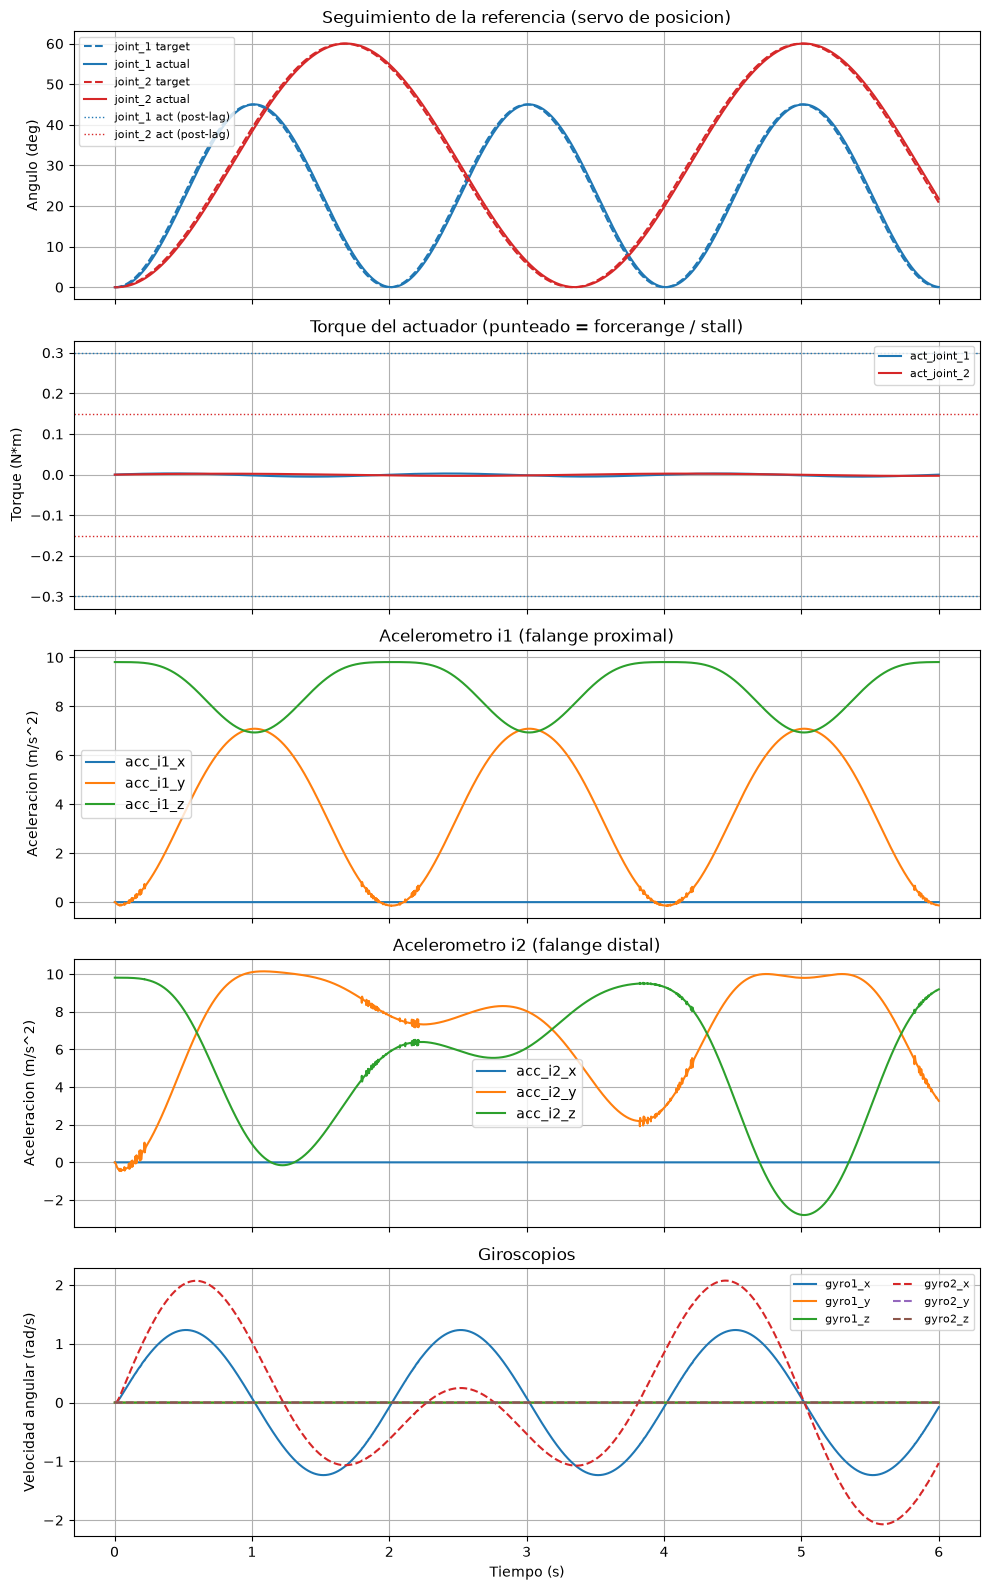

In [8]:
fig, axes = plt.subplots(5, 1, figsize=(10, 16), sharex=True)

axes[0].plot(log_time, np.rad2deg(log_qtarget[:, 0]), "--", color="tab:blue", label="joint_1 target")
axes[0].plot(log_time, np.rad2deg(log_qpos[:, 0]), color="tab:blue", label="joint_1 actual")
axes[0].plot(log_time, np.rad2deg(log_qtarget[:, 1]), "--", color="tab:red", label="joint_2 target")
axes[0].plot(log_time, np.rad2deg(log_qpos[:, 1]), color="tab:red", label="joint_2 actual")
# act = setpoint despues del filtro del motor. La separacion target -> act es
# exactamente la dinamica que model_ekf NO modela.
axes[0].plot(log_time, np.rad2deg(log_act[:, 0]), ":", color="tab:blue", lw=1, label="joint_1 act (post-lag)")
axes[0].plot(log_time, np.rad2deg(log_act[:, 1]), ":", color="tab:red", lw=1, label="joint_2 act (post-lag)")
axes[0].set_ylabel("Angulo (deg)")
axes[0].set_title("Seguimiento de la referencia (servo de posicion)")
axes[0].legend(fontsize=8)
axes[0].grid(True)

# Torque entregado vs. torque de stall: muestra si el motor satura
axes[1].plot(log_time, log_torque[:, 0], color="tab:blue", label="act_joint_1")
axes[1].plot(log_time, log_torque[:, 1], color="tab:red", label="act_joint_2")
for i, color in enumerate(["tab:blue", "tab:red"]):
    axes[1].axhline(model_sim.actuator_forcerange[i, 1], color=color, ls=":", lw=1)
    axes[1].axhline(model_sim.actuator_forcerange[i, 0], color=color, ls=":", lw=1)
axes[1].set_ylabel("Torque (N*m)")
axes[1].set_title("Torque del actuador (punteado = forcerange / stall)")
axes[1].legend(fontsize=8)
axes[1].grid(True)

for k, axis in enumerate("xyz"):
    axes[2].plot(log_time, log_acc1[:, k], label=f"acc_i1_{axis}")
axes[2].set_ylabel("Aceleracion (m/s^2)")
axes[2].set_title("Acelerometro i1 (falange proximal)")
axes[2].legend()
axes[2].grid(True)

for k, axis in enumerate("xyz"):
    axes[3].plot(log_time, log_acc2[:, k], label=f"acc_i2_{axis}")
axes[3].set_ylabel("Aceleracion (m/s^2)")
axes[3].set_title("Acelerometro i2 (falange distal)")
axes[3].legend()
axes[3].grid(True)

for k, axis in enumerate("xyz"):
    axes[4].plot(log_time, log_gyro1[:, k], label=f"gyro1_{axis}")
for k, axis in enumerate("xyz"):
    axes[4].plot(log_time, log_gyro2[:, k], "--", label=f"gyro2_{axis}")
axes[4].set_xlabel("Tiempo (s)")
axes[4].set_ylabel("Velocidad angular (rad/s)")
axes[4].set_title("Giroscopios")
axes[4].legend(ncol=2, fontsize=8)
axes[4].grid(True)

plt.tight_layout()
plt.show()

In [9]:
# Linealizacion por diferencias finitas -> A, B, C, D del EKF.
#
# Se usa model_ekf (4 estados), NO model_sim (6 estados): ver la celda markdown de
# arriba. En el modelo de 6 estados u entra solo por las activaciones, asi que
# recortar el resultado a 4x4 da un modelo mal, no un modelo aproximado.
#
# mjd_transitionFD calcula CUATRO jacobianos, no dos, y la firma los exige a todos
# (pueden ser None, pero no se pueden omitir) -> pasar solo (A, B) da TypeError:
#     mjd_transitionFD(m, d, eps, flg_centered, A, B, C, D)
#         A = d(x_next)/dx   (nx, nx)      B = d(x_next)/du   (nx, nu)
#         C = d(sensor)/dx   (ns, nx)      D = d(sensor)/du   (ns, nu)

# 1. Punto de operacion EXPLICITO. Si no, se linealiza en el estado en que quedo el
#    loop de simulacion (t = 6 s), que no es un punto elegido a proposito.
#    En un EKF real esto se rehace en cada paso alrededor del estado estimado.
x_op = np.array([np.deg2rad(20), np.deg2rad(-15), 0.0, 0.0])  # [q1, q2, v1, v2]

mj.mj_resetData(model_ekf, data_ekf)
data_ekf.qpos[:] = x_op[:model_ekf.nv]
data_ekf.qvel[:] = x_op[model_ekf.nv:]
data_ekf.ctrl[:] = data_ekf.qpos     # setpoint del servo = pose actual (equilibrio)
mj.mj_forward(model_ekf, data_ekf)   # model_ekf.na == 0 -> no hay data.act que setear

# 2. Dimensiones. El estado de MuJoCo usa el espacio tangente (nv) para las
#    posiciones, asi maneja bien las cuaterniones: nx = 2*nv + na. Aca na = 0.
nx = state_dim(model_ekf)
nu = model_ekf.nu
ns = model_ekf.nsensordata
print(f"nv={model_ekf.nv}, na={model_ekf.na}  ->  nx={nx}, nu={nu}, nsensordata={ns}")

# 3. Salidas preasignadas: float64, C-contiguas y escribibles (np.zeros ya cumple).
A = np.zeros((nx, nx))
B = np.zeros((nx, nu))
C = np.zeros((ns, nx))
D = np.zeros((ns, nu))

# 4. Parametros de la diferenciacion finita
eps = 1e-6           # tamano de la perturbacion
flg_centered = True  # diferencias centradas: mas preciso, ~2x mas caro que forward

# 5. Calcular. La funcion maneja sola los warmstarts del solver y el clamping de ctrl.
mj.mjd_transitionFD(model_ekf, data_ekf, eps, flg_centered, A, B, C, D)

print(f"A (dx_next/dx)  {A.shape}")
print(f"B (dx_next/du)  {B.shape}")
print(f"C (dsensor/dx)  {C.shape}")
print(f"D (dsensor/du)  {D.shape}")

# C es justamente el jacobiano del modelo de medicion (la H del EKF): filas = canales
# de sensordata, columnas = estado. Ej.: las 3 filas del acelerometro de la falange
# proximal respecto del estado completo.
acc1_adr = model_ekf.sensor("acc_i1").adr[0]
print("\nH del acc_i1 (3 x nx) =\n", C[acc1_adr:acc1_adr + 3])
print("Matriz A: ")
display(A)
print("Matriz B: ")
display(B)
print("Matriz C: ")
display(C)
print("Matriz D: ")
display(D)

nv=2, na=0  ->  nx=4, nu=2, nsensordata=18
A (dx_next/dx)  (4, 4)
B (dx_next/du)  (4, 2)
C (dsensor/dx)  (18, 4)
D (dsensor/du)  (18, 2)

H del acc_i1 (3 x nx) =
 [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 7.16346444e+02 -3.32055820e+01  9.91013165e+00 -5.29233837e-01]
 [-3.35521761e+00  1.77635684e-09  0.00000000e+00 -8.88178420e-10]]
Matriz A: 


array([[ 9.24323740e-01,  1.60987226e-03,  9.39411521e-04,
         2.55185595e-05],
       [ 4.01930494e-03,  9.31269823e-01,  5.58218749e-05,
         8.99753244e-04],
       [-3.78381298e+01,  8.04936134e-01,  4.69705765e-01,
         1.27592846e-02],
       [ 2.00965247e+00, -3.43650884e+01,  2.79109351e-02,
         4.49876624e-01]])

Matriz B: 


array([[ 7.57563194e-02, -1.59491056e-03],
       [-3.98727645e-03,  6.87654221e-02],
       [ 3.78781597e+01, -7.97455290e-01],
       [-1.99363823e+00,  3.43827110e+01]])

Matriz C: 


array([[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-3.28892417e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-1.19707050e-02,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 7.16346444e+02, -3.32055820e+01,  9.91013165e+00,
        -5.29233837e-01],
       [-3.35521761e+00,  1.77635684e-09,  0.00000000e+00,
        -8.88178420e-10],
       [ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00],
       [-6.27750827e-02, -2.98858409e-02,  0.00000000e+00,
         0.00000000e+00],
       [-1.45853773e-02, -2.61467228e-03,  0.00000000e+00,
      

Matriz D: 


array([[ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 7.07866548e+02, -3.30771148e+01],
       [-8.88178420e-10,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 1.90335638e+03,  4.82709431e+02],
       [ 3.66418688e+02, -1.71219745e+01],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00],
       [ 0.00000000e+00,  0.00000000e+00]])

In [10]:
np.set_printoptions(precision=6, suppress=True, linewidth=120)

print("A del EKF (4x4) =\n", A)
print("\nB del EKF (4x2) =\n", B)

# ---------------------------------------------------------------------------
# Por que NO se puede recortar el modelo de 6 estados: linealizamos la planta en
# el mismo punto de operacion y comparamos.
# ---------------------------------------------------------------------------
mj.mj_resetData(model_sim, data_sim)
data_sim.qpos[:] = x_op[:model_sim.nv]
data_sim.qvel[:] = x_op[model_sim.nv:]
data_sim.ctrl[:] = data_sim.qpos
data_sim.act[:] = data_sim.ctrl   # filtro del motor ya asentado -> equilibrio
mj.mj_forward(model_sim, data_sim)

nx_sim = state_dim(model_sim)
A_sim = np.zeros((nx_sim, nx_sim))
B_sim = np.zeros((nx_sim, model_sim.nu))
C_sim = np.zeros((model_sim.nsensordata, nx_sim))
D_sim = np.zeros((model_sim.nsensordata, model_sim.nu))
mj.mjd_transitionFD(model_sim, data_sim, eps, flg_centered, A_sim, B_sim, C_sim, D_sim)

print("\nB de la planta (6x2), recortada a sus 4 primeras filas =\n", B_sim[:4])

# El recorte no es cero (actearly="true" deja pasar parte del ctrl en el mismo paso),
# pero esta escalado por la ganancia de un paso del filtro: 1 - exp(-dt/tau).
one_step_gain = 1 - np.exp(-model_sim.opt.timestep / actuators["act_joint_1"]["tau"])
print(f"\nB_sim[:4] / B_ekf  ~  {np.median(B_sim[:4] / B):.6f}")
print(f"1 - exp(-dt/tau)   =  {one_step_gain:.6f}   <- coinciden: el recorte es B mal escalada")
print("Con actearly=false el recorte daria exactamente 0 (el EKF creeria que u no hace nada).")
print("Y ademas el recorte de A tira las columnas de 'a', que llevaban el resto del efecto.")

A del EKF (4x4) =
 [[  0.924324   0.00161    0.000939   0.000026]
 [  0.004019   0.93127    0.000056   0.0009  ]
 [-37.83813    0.804936   0.469706   0.012759]
 [  2.009652 -34.365088   0.027911   0.449877]]

B del EKF (4x2) =
 [[ 0.075756 -0.001595]
 [-0.003987  0.068765]
 [37.87816  -0.797455]
 [-1.993638 34.382711]]

B de la planta (6x2), recortada a sus 4 primeras filas =
 [[ 0.029808 -0.000628]
 [-0.001569  0.027057]
 [14.903894 -0.313774]
 [-0.784436 13.528543]]

B_sim[:4] / B_ekf  ~  0.393469
1 - exp(-dt/tau)   =  0.393469   <- coinciden: el recorte es B mal escalada
Con actearly=false el recorte daria exactamente 0 (el EKF creeria que u no hace nada).
Y ademas el recorte de A tira las columnas de 'a', que llevaban el resto del efecto.


## Does the 4x4 `A` actually describe the system?

`mjd_transitionFD` returned an `A`; that it has the right shape proves nothing. The
cells below propagate the state with `A` alone and compare against what MuJoCo
actually produces.

Three things this test has to get right to be worth running:

**1. Ground truth is `model_ekf`, not `model_sim`.** `A` was linearised on the
4-state model. Scoring it against the 6-state plant measures linearisation error
*and* the 4 ms motor lag at the same time — two different problems with two
different fixes (relinearise vs. inflate `Q`). The plant comparison is run at the
end, deliberately, as a separate experiment.

**2. `A` is a Jacobian, so the model is in deviations**, not in absolute state:

$$x_i \;\approx\; f(x_{op}, u_{op}) \;+\; A\,(x_{i-1} - x_{op}) \;+\; B\,(u_{i-1} - u_{op})$$

The affine term is not decoration: $x_{op}$ is **not** an equilibrium here (the servo
sits at rest, but gravity keeps pulling), so $f(x_{op},u_{op}) \neq x_{op}$.

**3. "Small error" is meaningless without a scale.** At `dt = 2 ms` the state barely
moves in one step, so *any* model — including a badly wrong one — posts a small
absolute one-step error. Errors are reported relative to the real per-step motion
$\lVert \Delta q \rVert$, and a deliberately corrupted `A` goes through the identical
test as a control.

Two propagation modes, because they falsify different things:

| | given | catches |
|---|---|---|
| **one step** | the real $x_{i-1}$, every step | model error with no accumulation — the direct answer to "does `A` describe the system" |
| **open loop** | only $x_0$, then its own output | the velocity rows, which the $q$ error alone **cannot** falsify |


In [11]:
# ============================================================================
# VALIDACION DE A: q real vs q propagado por A, partiendo solo de x[i-1]
# ============================================================================
# La referencia se corre sobre model_ekf, que es el sistema que A describe.
# Contra model_sim se compara al final, aparte: ahi se suma el lag del motor,
# que es error de MODELADO, no de linealizacion.

u_op = x_op[:model_ekf.nv].copy()   # en la celda de linealizacion: ctrl = qpos


def step_once(model, data, x, u):
    """Un mj_step desde (x, u) -> x_next = [qpos, qvel]. Sin estado residual."""
    nv = model.nv
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    data.ctrl[:] = u
    mj.mj_step(model, data)
    return np.concatenate([data.qpos[:nv].copy(), data.qvel[:nv].copy()])


# Termino afin. x_op NO es equilibrio: el servo esta en reposo pero la gravedad
# sigue tirando -> f(x_op,u_op) != x_op y el modelo en desviaciones lo necesita.
x_next_op = step_once(model_ekf, data_ekf, x_op, u_op)
print("x_op                       =", x_op)
print("f(x_op, u_op)              =", x_next_op)
print("deriva f(x_op,u_op) - x_op =", x_next_op - x_op)

# Constante del modelo afin escrito en forma absoluta: x_next = A x + B u + c.
# Se mide, no se supone: aca c es chica (~1e-3 del estado), asi que en ESTE punto
# de operacion la forma absoluta ingenua casi coincide con la correcta. No es una
# licencia para tirar el termino: c no tiene por que ser chica en otro x_op.
c_affine = x_next_op - A @ x_op - B @ u_op
print(f"c = f(x_op,u_op) - A x_op - B u_op = {c_affine}")
print(f"  |c| = {np.linalg.norm(c_affine):.3e}  ({np.linalg.norm(c_affine)/np.linalg.norm(x_next_op):.2%} del estado)")


def reference_targets(t):
    """Mismas referencias que la simulacion de arriba (raised cosine por joint)."""
    return np.array([sine_target(sine_params["joint_1"], t)[0],
                     sine_target(sine_params["joint_2"], t)[0]])


def rollout(model, data, n_steps):
    """Trayectoria real. X[k] = estado ANTES del paso k, U[k] = ctrl durante el paso k.
    Se loguea antes de mj_step (y no despues, como el loop del video) para que
    X[k] -> X[k+1] sea exactamente un paso, sin corrimiento de indices."""
    nv = model.nv
    X = np.zeros((n_steps + 1, 2 * nv))
    U = np.zeros((n_steps, model.nu))
    T = np.zeros(n_steps + 1)
    mj.mj_resetData(model, data)
    for k in range(n_steps):
        X[k, :nv], X[k, nv:] = data.qpos[:nv], data.qvel[:nv]
        T[k] = data.time
        U[k] = reference_targets(data.time)
        data.ctrl[:] = U[k]
        mj.mj_step(model, data)
    X[n_steps, :nv], X[n_steps, nv:] = data.qpos[:nv], data.qvel[:nv]
    T[n_steps] = data.time
    return T, X, U


def predict(Amat, Bmat, x, u):
    """Modelo linealizado en DESVIACIONES respecto a (x_op, u_op)."""
    return x_next_op + Amat @ (x - x_op) + Bmat @ (u - u_op)


n_val = int(sim_duration / model_ekf.opt.timestep)
T_val, X_val, U_val = rollout(model_ekf, data_ekf, n_val)

# (1) UN PASO: predice x[i] desde el x[i-1] REAL -> error de modelo sin acumulacion.
pred_1step = np.array([predict(A, B, X_val[k], U_val[k]) for k in range(n_val)])
err_1step = pred_1step - X_val[1:]

# (2) LAZO ABIERTO: se le da solo x[0] y se realimenta su propia salida.
pred_free = np.zeros_like(X_val)
pred_free[0] = X_val[0]
for k in range(n_val):
    pred_free[k + 1] = predict(A, B, pred_free[k], U_val[k])
err_free = pred_free[1:] - X_val[1:]

# Escala: cuanto se mueve el estado en UN paso. Sin esto "0.001 deg de error" no
# dice nada, porque con dt = 2 ms hasta un modelo malo da error chico por paso.
dX_val = np.diff(X_val, axis=0)
step_motion = np.linalg.norm(dX_val[:, :2], axis=1)
rel_1step = np.linalg.norm(err_1step[:, :2], axis=1) / np.maximum(step_motion, 1e-12)

print(f"\n{n_val} pasos de {model_ekf.opt.timestep*1000:.0f} ms")
print(f"movimiento real por paso |dq|: mediana {np.rad2deg(np.median(step_motion)):.4f} deg")
print(f"radio espectral de A = {np.abs(np.linalg.eigvals(A)).max():.4f} "
      "(<1 -> el error de linealizacion se amortigua, no se acumula)")
print("\n--- prediccion a UN paso (desde el x[i-1] real) ---")
for j, nm in enumerate(("q1", "q2")):
    print(f"  {nm}: max |err| = {np.rad2deg(np.abs(err_1step[:, j])).max():.3e} deg")
for j, nm in enumerate(("v1", "v2")):
    print(f"  {nm}: max |err| = {np.rad2deg(np.abs(err_1step[:, 2 + j])).max():.3e} deg/s")
print(f"  error en q relativo al movimiento por paso: mediana {np.median(rel_1step):.3%}")
print("--- lazo abierto (solo x[0]) ---")
for j, nm in enumerate(("q1", "q2")):
    print(f"  {nm}: max |err| = {np.rad2deg(np.abs(err_free[:, j])).max():.3e} deg")


x_op                       = [ 0.349066 -0.261799  0.        0.      ]
f(x_op, u_op)              = [ 0.349091 -0.261798  0.012476  0.000929]
deriva f(x_op,u_op) - x_op = [0.000025 0.000002 0.012476 0.000929]
c = f(x_op,u_op) - A x_op - B u_op = [ 0.000001 -0.        0.000461 -0.000048]
  |c| = 4.634e-04  (0.11% del estado)

3000 pasos de 2 ms
movimiento real por paso |dq|: mediana 0.1292 deg
radio espectral de A = 0.8550 (<1 -> el error de linealizacion se amortigua, no se acumula)

--- prediccion a UN paso (desde el x[i-1] real) ---
  q1: max |err| = 9.291e-04 deg
  q2: max |err| = 1.744e-03 deg
  v1: max |err| = 4.645e-01 deg/s
  v2: max |err| = 8.719e-01 deg/s
  error en q relativo al movimiento por paso: mediana 0.275%
--- lazo abierto (solo x[0]) ---
  q1: max |err| = 1.282e-02 deg
  q2: max |err| = 2.610e-02 deg


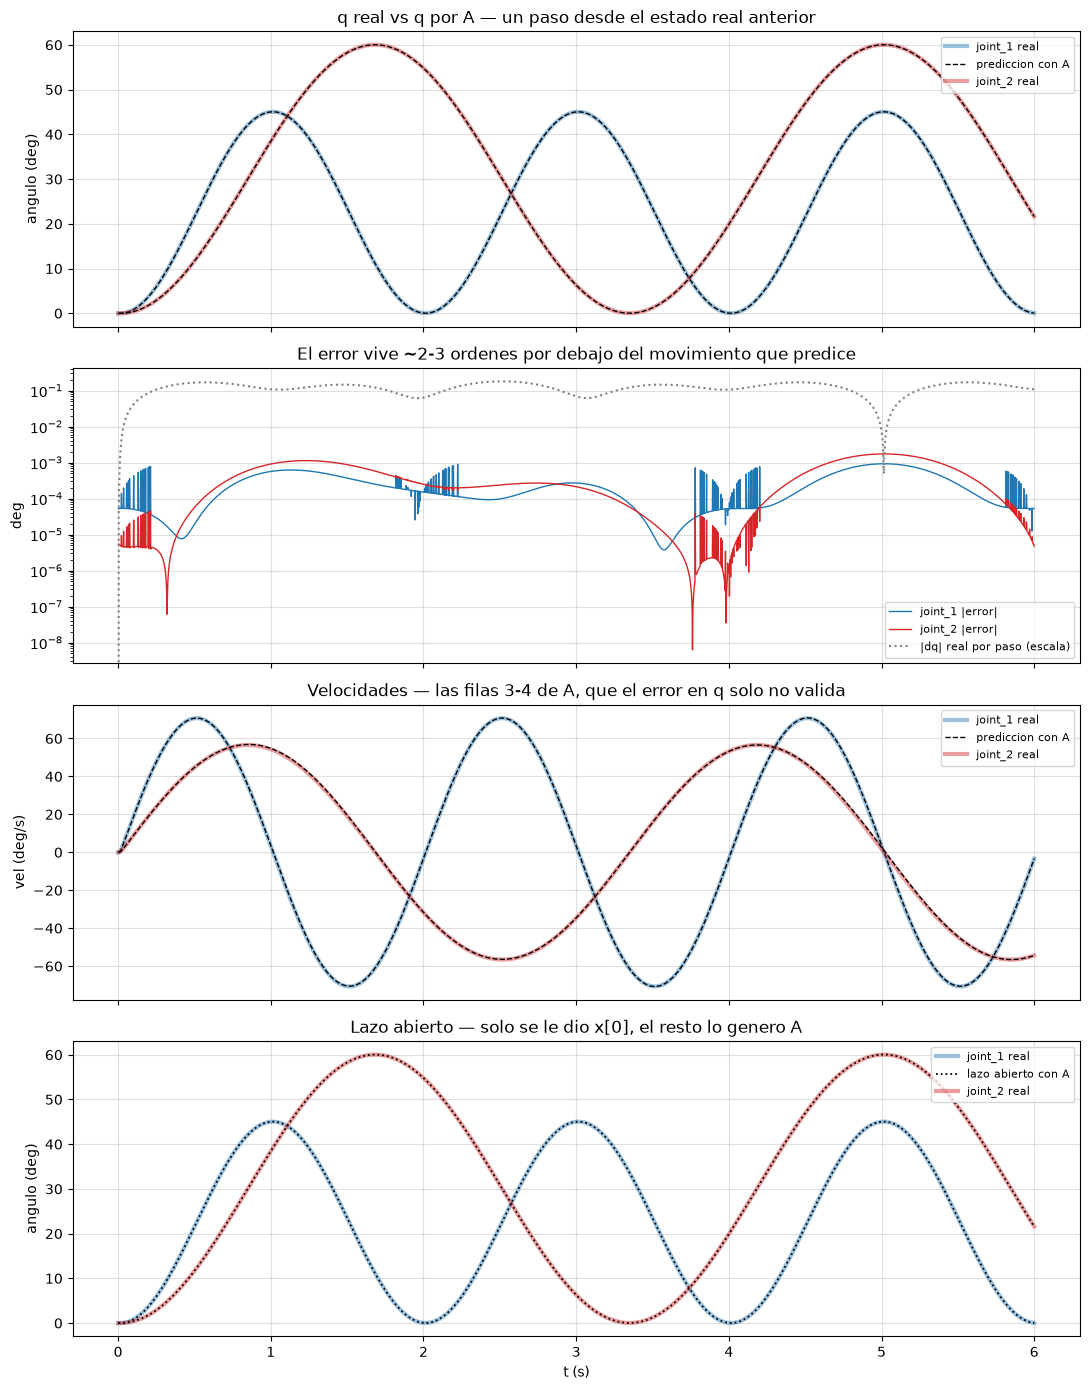

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(4, 1, figsize=(11, 14), sharex=True)
colors = ("tab:blue", "tab:red")
names = ("joint_1", "joint_2")

# --- 1. q real vs q por A, a un paso ---------------------------------------
for j in range(2):
    axes[0].plot(T_val[1:], np.rad2deg(X_val[1:, j]), color=colors[j], lw=3, alpha=.45,
                 label=f"{names[j]} real")
    axes[0].plot(T_val[1:], np.rad2deg(pred_1step[:, j]), "--", color="k", lw=1,
                 label="prediccion con A" if j == 0 else None)
axes[0].set_ylabel("angulo (deg)")
axes[0].set_title("q real vs q por A — un paso desde el estado real anterior")
axes[0].legend(fontsize=8, loc="upper right")
axes[0].grid(True, alpha=.4)

# --- 2. error contra la escala del movimiento ------------------------------
for j in range(2):
    axes[1].plot(T_val[1:], np.rad2deg(np.abs(err_1step[:, j])), color=colors[j], lw=1,
                 label=f"{names[j]} |error|")
axes[1].plot(T_val[1:], np.rad2deg(step_motion), color="gray", ls=":", lw=1.5,
             label="|dq| real por paso (escala)")
axes[1].set_yscale("log")
axes[1].set_ylabel("deg")
axes[1].set_title("El error vive ~2-3 ordenes por debajo del movimiento que predice")
axes[1].legend(fontsize=8, loc="lower right")
axes[1].grid(True, which="major", alpha=.4)

# --- 3. velocidades: filas 3-4 de A ----------------------------------------
for j in range(2):
    axes[2].plot(T_val[1:], np.rad2deg(X_val[1:, 2 + j]), color=colors[j], lw=3, alpha=.45,
                 label=f"{names[j]} real")
    axes[2].plot(T_val[1:], np.rad2deg(pred_1step[:, 2 + j]), "--", color="k", lw=1,
                 label="prediccion con A" if j == 0 else None)
axes[2].set_ylabel("vel (deg/s)")
axes[2].set_title("Velocidades — las filas 3-4 de A, que el error en q solo no valida")
axes[2].legend(fontsize=8, loc="upper right")
axes[2].grid(True, alpha=.4)

# --- 4. lazo abierto --------------------------------------------------------
for j in range(2):
    axes[3].plot(T_val[1:], np.rad2deg(X_val[1:, j]), color=colors[j], lw=3, alpha=.45,
                 label=f"{names[j]} real")
    axes[3].plot(T_val[1:], np.rad2deg(pred_free[1:, j]), ":", color="k", lw=1.3,
                 label="lazo abierto con A" if j == 0 else None)
axes[3].set_ylabel("angulo (deg)")
axes[3].set_xlabel("t (s)")
axes[3].set_title("Lazo abierto — solo se le dio x[0], el resto lo genero A")
axes[3].legend(fontsize=8, loc="upper right")
axes[3].grid(True, alpha=.4)

fig.tight_layout()
plt.show()


In [13]:
# ============================================================================
# CONTROL: un test que no reprueba una A mal, no prueba nada
# ============================================================================
# Las curvas de arriba se superponen. Eso solo vale si el mismo test separa una A
# correcta de una corrupta -> se corrompe A a proposito y se vuelve a medir.

def score(Amat, Bmat, label):
    p1 = np.array([predict(Amat, Bmat, X_val[k], U_val[k]) for k in range(n_val)])
    e1 = p1 - X_val[1:]
    pf = np.zeros_like(X_val)
    pf[0] = X_val[0]
    for k in range(n_val):
        pf[k + 1] = predict(Amat, Bmat, pf[k], U_val[k])
    rel = np.median(np.linalg.norm(e1[:, :2], axis=1) / np.maximum(step_motion, 1e-12))
    free_max = np.rad2deg(np.abs(pf[1:, :2] - X_val[1:, :2])).max()
    print(f"  {label:34} q rel/paso {rel:10.3%} | lazo abierto max {free_max:.3e} deg")


print("modelo                             error en q por paso | divergencia en lazo abierto")
print("-" * 96)
score(A, B, "A, B correctas")
score(np.eye(4), B, "MAL: A = I")
score(A * 1.01, B, "MAL: A escalada 1%")
A_bad = A.copy()
A_bad[2, 0] = 0.0
score(A_bad, B, "MAL: A[2,0] = 0 (rigidez servo)")
score(A, np.zeros_like(B), "MAL: B = 0")
print("\n  Un error del 1% en A multiplica por ~1300 el error por paso: el test discrimina.")
print("  Pero A[2,0]=0 deja el error en q IDENTICO — es una fila de VELOCIDAD, y a un")
print("  paso no toca q. Solo el lazo abierto lo delata (~850x peor). Validar q sola")
print("  deja sin testear medio A; por eso estan los dos modos.")

# --- definicion de derivada: A dx debe reproducir f(x_op+dx) - f(x_op) --------
print("\nTest de perturbacion  f(x_op+dx) - f(x_op)  vs  A dx:")
rng = np.random.default_rng(0)
for scale in (1e-6, 1e-4, 1e-2, 1e-1):
    rel = []
    for _ in range(20):
        dx = rng.normal(size=4) * scale
        true_d = step_once(model_ekf, data_ekf, x_op + dx, u_op) - x_next_op
        rel.append(np.linalg.norm(true_d - A @ dx) / max(np.linalg.norm(true_d), 1e-300))
    print(f"  |dx| ~ {scale:.0e}  ->  error relativo mediano {np.median(rel):.2e}")
print("  El error cae ~linealmente con |dx|: es el termino de 2do orden, o sea A es")
print("  exactamente la derivada. Es la comprobacion mas fuerte de las tres.")

# --- contra la PLANTA: esto ya no mide linealizacion, mide modelado ----------
T_p, X_p, U_p = rollout(model_sim, data_sim, n_val)
err_plant = np.array([predict(A, B, X_p[k], U_p[k]) for k in range(n_val)]) - X_p[1:]
q_ekf = np.rad2deg(np.abs(err_1step[:, :2])).max()
q_plant = np.rad2deg(np.abs(err_plant[:, :2])).max()
print(f"\nContra model_sim (planta con lag de motor de 4 ms):")
print(f"  q max |err| = {q_plant:.3e} deg   vs   {q_ekf:.3e} deg contra model_ekf"
      f"   -> {q_plant / q_ekf:.0f}x")
print("  Ese factor NO es culpa de A: es el estado de activacion que model_ekf no")
print("  tiene. Es exactamente lo que hay que cubrir inflando los terminos de")
print("  velocidad de Q, tal como dice la celda del modelo dual.")


modelo                             error en q por paso | divergencia en lazo abierto
------------------------------------------------------------------------------------------------
  A, B correctas                     q rel/paso     0.275% | lazo abierto max 2.610e-02 deg
  MAL: A = I                         q rel/paso  2679.423% | lazo abierto max 9.752e+03 deg
  MAL: A escalada 1%                 q rel/paso   351.070% | lazo abierto max 5.620e+00 deg
  MAL: A[2,0] = 0 (rigidez servo)    q rel/paso     0.275% | lazo abierto max 2.225e+01 deg
  MAL: B = 0                         q rel/paso  2688.624% | lazo abierto max 7.502e+01 deg

  Un error del 1% en A multiplica por ~1300 el error por paso: el test discrimina.
  Pero A[2,0]=0 deja el error en q IDENTICO — es una fila de VELOCIDAD, y a un
  paso no toca q. Solo el lazo abierto lo delata (~850x peor). Validar q sola
  deja sin testear medio A; por eso estan los dos modos.

Test de perturbacion  f(x_op+dx) - f(x_op)  vs  A dx:
  |dx

## Measurement model: `h` and `H`, kept separate

The prediction side is covered above (`A`, `B`). This is the other half of the EKF:
the measurement function and its Jacobian.

They are two functions, not one, because the filter calls them at different rates —
`h` on every innovation (one `mj_forward`), `H` only when relinearising (`2*nx`
finite-difference evaluations). Returning both together forces you to pay for `H`
every time you only wanted `z_pred`.

Three things that are easy to get wrong here, all checked in the verification cell:

- **`h` takes `u`, not just `x`.** The accelerometers read `qacc`, and `qacc`
  depends on the servo torque. `D = ∂h/∂u` is nonzero for `acc_i1`/`acc_i2` and
  exactly zero for the gyros and position sensors — so an innovation built as
  `z - h(x)` is biased in the accelerometer channels.
- **`mj_forward`, not a cheaper stage.** `mjSENS_ACC` sensors are only valid after
  the acceleration stage; stopping at `mj_fwdPosition + mj_sensorPos` leaves
  `acc_i1` and `acc_i2` wrong while the other four sensors already look fine.
- **`H` is `mjd_transitionFD`'s `C`, not `mjd_inverseFD`'s `DsDq`.** The latter are
  partials with `(q, v, a)` held independent; they ignore `∂a/∂q`. For the
  `acc_i1_y` row that is 9.22 versus a true 716.35.

One related gotcha that bites when validating `h` against logged data: **`mj_step`
does not refresh `sensordata`**. After `mj_step`, `data.sensordata` still holds the
readings of the *pre-integration* state, so the logging loop further up pairs
`log_qpos[k]` (post-step) with sensor samples from one step earlier. Call
`mj_forward` after the step before logging sensors, or log them before stepping.


In [15]:
# ============================================================================
# MODELO DE MEDICION: h y H, separados
# ============================================================================
# Van aparte a proposito. En un EKF se llaman en momentos distintos: h en cada
# innovacion (barato, un mj_forward), H solo cuando toca relinealizar (caro,
# 2*nx diferencias finitas). Fusionarlos obliga a pagar H cada vez que se quiere
# un z_pred.
#
# MjData propio: las dos funciones hacen mj_resetData, y mjd_transitionFD ademas
# perturba el estado. Llamarlas con data_sim en medio del loop de simulacion
# romperia la simulacion en curso.
data_meas = mj.MjData(model_ekf)


def sensor_slice(name, model=model_ekf):
    """Filas de sensordata (y de H) que ocupa un sensor."""
    s = model.sensor(name)
    adr, dim = int(s.adr[0]), int(s.dim[0])
    return slice(adr, adr + dim)


def measurement_h(x, u, model=model_ekf, data=None):
    """z = h(x, u) — que leerian los sensores en el estado x con el control u.

    x : (nx,) estado MuJoCo [qpos, qvel], en BLOQUES (no intercalado)
    u : (nu,) ctrl = angulo objetivo del servo, rad
    ->  (nsensordata,) lectura de sensores, en las unidades de cada sensor
        (acelerometros m/s^2 y giroscopos rad/s, ambos en marco del sitio)

    Depende de u, no solo de x: los acelerometros leen qacc, y qacc depende del
    torque que entrega el servo. Por eso mj_forward y no una etapa mas barata:
    los sensores mjSENS_ACC recien quedan bien despues de la etapa de
    aceleracion (con mj_fwdPosition + mj_sensorPos, acc_i1 y acc_i2 salen mal).
    mj_forward NO integra: deja los sensores evaluados en x, que es lo que
    corresponde a la innovacion z - h(x_pred, u).
    """
    data = data_meas if data is None else data
    nv = model.nv
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    data.ctrl[:] = u
    mj.mj_forward(model, data)
    return data.sensordata.copy()


def measurement_H(x, u, model=model_ekf, data=None, eps=1e-6, centered=True):
    """H = dh/dx evaluado en (x, u).  -> (nsensordata, nx)

    Es el bloque C de mjd_transitionFD: la derivada TOTAL de los sensores
    respecto del estado ACTUAL (verificado abajo contra diferencias finitas de
    measurement_h, y contra la C de la celda de linealizacion).

    No usar las parciales DsDq/DsDv/DsDa de mjd_inverseFD para esto: tratan
    (q, v, a) como independientes e ignoran da/dq, asi que no son el H de un
    EKF. Para la fila acc_i1_y dan 9.22 donde la total vale 716.35.
    """
    data = data_meas if data is None else data
    nv = model.nv
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    data.ctrl[:] = u
    mj.mj_forward(model, data)
    H = np.zeros((model.nsensordata, state_dim(model)))
    # A, B y D van como None: aca solo interesa el bloque de medicion.
    mj.mjd_transitionFD(model, data, eps, centered, None, None, H, None)
    return H


In [16]:
# --- verificacion -----------------------------------------------------------
u_meas = x_op[:model_ekf.nv].copy()      # ctrl = pose actual, igual que al linealizar

z_op = measurement_h(x_op, u_meas)
H_op = measurement_H(x_op, u_meas)
print(f"z = h(x_op, u)  -> {z_op.shape}")
print(f"H = dh/dx       -> {H_op.shape}")


def _fd_H(x, u, eps=1e-6):
    """Diferencias centradas sobre measurement_h: H tiene que ser esto."""
    J = np.zeros((model_ekf.nsensordata, x.size))
    for i in range(x.size):
        e = np.zeros(x.size)
        e[i] = eps
        J[:, i] = (measurement_h(x + e, u) - measurement_h(x - e, u)) / (2 * eps)
    return J


print(f"\nmax |H - FD(measurement_h)| = {np.abs(H_op - _fd_H(x_op, u_meas)).max():.3e}"
      "   -> H es efectivamente la derivada de h")
print(f"H identico a la C de la celda de linealizacion? {np.allclose(H_op, C, atol=1e-12)}")

# h depende de u: si el EKF calcula z_pred = h(x) a secas, se come este termino.
z_u = measurement_h(x_op, u_meas + np.deg2rad([10.0, 0.0]))
print("\nMoviendo SOLO u (+10 deg en el target de joint_1), con x fijo:")
for nm in ("acc_i1", "acc_i2", "gyro1", "pos_c"):
    sl = sensor_slice(nm)
    print(f"  {nm:8} max |dz| = {np.abs(z_u[sl] - z_op[sl]).max():.4e}")
print("  -> los acelerometros se mueven; z_pred = h(x, u), NO h(x).")

# Bloques por sensor: asi se arma el update de un subconjunto de sensores.
print("\nH por sensor (filas, rank):")
for i in range(model_ekf.nsensor):
    nm = model_ekf.sensor(i).name
    blk = H_op[sensor_slice(nm)]
    print(f"  {nm:16} {str(blk.shape):8} rank={np.linalg.matrix_rank(blk, tol=1e-8)}")

print("\nH de acc_i1 (3 x nx) =\n", H_op[sensor_slice("acc_i1")])
print("\nUso en el update del EKF, para un subconjunto de sensores:")
print("  sl = sensor_slice('acc_i1')")
print("  y  = z[sl] - measurement_h(x_pred, u)[sl]     # innovacion")
print("  Hs = measurement_H(x_pred, u)[sl]             # (3, nx)")
print("  S  = Hs @ P @ Hs.T + R[sl, sl]")


z = h(x_op, u)  -> (18,)
H = dh/dx       -> (18, 4)

max |H - FD(measurement_h)| = 2.274e-13   -> H es efectivamente la derivada de h
H identico a la C de la celda de linealizacion? True

Moviendo SOLO u (+10 deg en el target de joint_1), con x fijo:
  acc_i1   max |dz| = 1.0618e+02
  acc_i2   max |dz| = 2.8550e+02
  gyro1    max |dz| = 0.0000e+00
  pos_c    max |dz| = 0.0000e+00
  -> los acelerometros se mueven; z_pred = h(x, u), NO h(x).

H por sensor (filas, rank):
  pos_punta_seg1   (3, 4)   rank=1
  acc_i1           (3, 4)   rank=2
  gyro1            (3, 4)   rank=1
  pos_c            (3, 4)   rank=2
  acc_i2           (3, 4)   rank=2
  gyro2            (3, 4)   rank=1

H de acc_i1 (3 x nx) =
 [[  0.         0.         0.         0.      ]
 [716.346444 -33.205582   9.910132  -0.529234]
 [ -3.355218   0.         0.        -0.      ]]

Uso en el update del EKF, para un subconjunto de sensores:
  sl = sensor_slice('acc_i1')
  y  = z[sl] - measurement_h(x_pred, u)[sl]     # innovacion

## EKF on the MuJoCo model

Everything the filter needs now exists: `f`/`F` from `mjd_transitionFD` on the
prediction side, `h`/`H` on the measurement side. This assembles them.

The filter is written against a *model argument*, not against `model_ekf`, so the
same class runs on either compiled model. That is the experiment: `model_sim`
(6 states, has the motor lag) is always the plant, and the filter is given either

| filter model | states | vs. the plant |
|---|---|---|
| `model_sim` | 6 — `[q, v, act]` | **matched** — same dynamics as the plant |
| `model_ekf` | 4 — `[q, v]` | **mismatched** — no motor-lag activation state |

The dual-model cell earlier says to cover the missing lag by inflating the velocity
terms of `Q`. The validation below tests that claim, and it does not survive: the
lag enters the *measurement* as well, as a deterministic bias, and no `Q` fixes a
biased `h`.

Three things this setup has to get right, all of which cost real debugging:

- **Time alignment.** `X[k]`, `Z[k]` and `U[k]` must refer to the same instant, so
  the plant loop logs *before* `mj_step` and `X[k+1] = f(X[k], U[k])` holds exactly.
  Logging after the step while reusing the earlier `u` desynchronises state,
  measurement and control by one step — worth ~0.13° here, which is the entire
  per-step motion, and it masquerades as a model error.
- **Known process noise.** With the matched model the prediction is *exact*, so
  `Q → 0`, `P` collapses, and NEES explodes on pure rounding. A consistency test
  needs a disturbance whose covariance you know, so the plant gets an explicit
  torque disturbance and `Q` is built to match it.
- **Keeping `P` positive definite.** `F` has entries of order 700 and `P` spans ten
  orders of magnitude between the position and velocity blocks; `F P Fᵀ` loses
  symmetry and positive-definiteness in floating point. Without an eigenvalue floor
  the NEES goes *negative* — the diagnostic silently becomes meaningless.


In [17]:
# ============================================================================
# EKF sobre modelo MuJoCo — generico en el modelo (4 o 6 estados)
# ============================================================================
from scipy.stats import chi2

SIG_ACC, SIG_GYR = 0.05, 0.005          # ruido de sensor: m/s^2 y rad/s
SIG_ALPHA = 12.0                        # perturbacion de torque: rad/s^2 (1 sigma)
SIG_ACT = 2e-4                          # jitter de la activacion del servo, rad
IMU = ("acc_i1", "gyro1", "acc_i2", "gyro2")


def rows_of(*names):
    """Indices de sensordata de un conjunto de sensores."""
    return np.concatenate([np.arange(sensor_slice(n).start, sensor_slice(n).stop)
                           for n in names])


def _load(model, data, x, u):
    """Estado del filtro -> MjData.  x = [qpos, qvel, act]; act solo si na > 0."""
    nv, na = model.nv, model.na
    mj.mj_resetData(model, data)
    data.qpos[:nv] = x[:nv]
    data.qvel[:nv] = x[nv:2 * nv]
    if na:
        data.act[:na] = x[2 * nv:2 * nv + na]
    data.ctrl[:] = u


def _dump(model, data):
    nv, na = model.nv, model.na
    p = [data.qpos[:nv].copy(), data.qvel[:nv].copy()]
    if na:
        p.append(data.act[:na].copy())
    return np.concatenate(p)


def f_dyn(x, u, model, data):
    """x_{k+1} = f(x_k, u_k) — un mj_step."""
    _load(model, data, x, u)
    mj.mj_step(model, data)
    return _dump(model, data)


def F_dyn(x, u, model, data, eps=1e-6):
    """F = df/dx — el bloque A de mjd_transitionFD."""
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    n = state_dim(model)
    F = np.zeros((n, n))
    mj.mjd_transitionFD(model, data, eps, True, F, None, None, None)
    return F


def h_dyn(x, u, model, data):
    """z = h(x, u) — generaliza measurement_h a modelos con activaciones."""
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    return data.sensordata.copy()


def H_dyn(x, u, model, data, eps=1e-6):
    """H = dh/dx — el bloque C de mjd_transitionFD."""
    _load(model, data, x, u)
    mj.mj_forward(model, data)
    H = np.zeros((model.nsensordata, state_dim(model)))
    mj.mjd_transitionFD(model, data, eps, True, None, None, H, None)
    return H


def make_spd(P, rel=1e-12):
    """Simetriza y pisa los autovalores. NO es cosmetico: F tiene entradas ~700 y
    P abarca ~10 ordenes entre el bloque de posicion y el de velocidad, asi que
    F P F^T pierde la definicion positiva en punto flotante. Sin esto el NEES sale
    NEGATIVO y el diagnostico deja de significar algo."""
    P = 0.5 * (P + P.T)
    w, V = np.linalg.eigh(P)
    w = np.maximum(w, max(w.max(), 0.0) * rel + 1e-300)
    return (V * w) @ V.T


class EKF:
    """EKF con f/F/h/H de MuJoCo. Update en forma de Joseph."""

    def __init__(self, x0, P0, Q, R, model, data):
        self.x = np.asarray(x0, float).copy()
        self.P = make_spd(np.asarray(P0, float))
        self.Q = np.asarray(Q, float)
        self.R = np.asarray(R, float)
        self.model, self.data = model, data

    def predict(self, u):
        F = F_dyn(self.x, u, self.model, self.data)
        self.x = f_dyn(self.x, u, self.model, self.data)
        self.P = make_spd(F @ self.P @ F.T + self.Q)

    def update(self, z, u, rows):
        """Devuelve (innovacion, NIS)."""
        H = H_dyn(self.x, u, self.model, self.data)[rows]
        y = z[rows] - h_dyn(self.x, u, self.model, self.data)[rows]
        R = self.R[np.ix_(rows, rows)]
        S = make_spd(H @ self.P @ H.T + R)
        K = np.linalg.solve(S, H @ self.P).T          # = P H^T S^-1
        self.x = self.x + K @ y
        I_KH = np.eye(self.x.size) - K @ H
        self.P = make_spd(I_KH @ self.P @ I_KH.T + K @ R @ K.T)
        return y, float(y @ np.linalg.solve(S, y))


def make_Q(model, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT):
    """Q de una perturbacion de aceleracion angular blanca (DWNA):
        w = G nu,  G = [dt^2/2 I ; dt I ; 0],  nu ~ N(0, sig_alpha^2 I)
    Da la correlacion q-v correcta, en vez de dos bloques diagonales sueltos."""
    nv, na, nx = model.nv, model.na, state_dim(model)
    G = np.zeros((nx, nv))
    for j in range(nv):
        G[j, j] = dt_sim ** 2 / 2
        G[nv + j, j] = dt_sim
    Q = G @ (sig_alpha ** 2 * np.eye(nv)) @ G.T
    for j in range(na):
        Q[2 * nv + j, 2 * nv + j] = sig_act ** 2
    return Q + np.eye(nx) * 1e-18


def make_R(model):
    """R diagonal a especificacion de sensor."""
    R = np.zeros((model.nsensordata,) * 2)
    for i in range(model.nsensor):
        nm = model.sensor(i).name
        sl = sensor_slice(nm)
        s = SIG_ACC if "acc" in nm else (SIG_GYR if "gyro" in nm else 1.0)
        for k in range(sl.start, sl.stop):
            R[k, k] = s ** 2
    return R


dt_sim = model_ekf.opt.timestep
print(f"dt = {dt_sim*1000:.0f} ms   IMU = {rows_of(*IMU).size} canales")
print("Q (model_ekf) =\n", make_Q(model_ekf))


dt = 2 ms   IMU = 12 canales
Q (model_ekf) =
 [[0.       0.       0.000001 0.      ]
 [0.       0.       0.       0.000001]
 [0.000001 0.       0.000576 0.      ]
 [0.       0.000001 0.       0.000576]]


In [18]:
# ============================================================================
# Planta + corrida del filtro
# ============================================================================
def plant_run(n_steps, seed, sig_alpha=SIG_ALPHA, sig_act=SIG_ACT):
    """Verdad de referencia sobre model_sim, con una perturbacion CONOCIDA.

    X[k], Z[k] en el instante t_k;  U[k] actua durante [t_k, t_{k+1}].
    Se loguea ANTES de mj_step -> X[k+1] = f(X[k], U[k]) exacto. Loguear despues
    del paso reusando el u anterior corre estado/medicion/control un paso entero.

    La perturbacion se aplica como aceleracion angular sobre el paso (dt^2/2 en
    posicion, dt en velocidad), que es justo el w que describe make_Q.
    """
    rng = np.random.default_rng(seed)
    nv = model_sim.nv
    mj.mj_resetData(model_sim, data_sim)
    X, Z, U = [], [], []
    for _ in range(n_steps):
        u = np.array([sine_target(sine_params["joint_1"], data_sim.time)[0],
                      sine_target(sine_params["joint_2"], data_sim.time)[0]])
        data_sim.ctrl[:] = u
        mj.mj_forward(model_sim, data_sim)      # sensores en el estado ACTUAL
        X.append(_dump(model_sim, data_sim))
        Z.append(data_sim.sensordata.copy())
        U.append(u)
        mj.mj_step(model_sim, data_sim)
        nu = rng.normal(0, sig_alpha, nv)
        data_sim.qpos[:nv] += dt_sim ** 2 / 2 * nu
        data_sim.qvel[:nv] += dt_sim * nu
        data_sim.act[:model_sim.na] += rng.normal(0, sig_act, model_sim.na)
    X.append(_dump(model_sim, data_sim))
    return np.array(X), np.array(Z), np.array(U)


def run_filter(model, X, Z, U, rows, seed=0):
    """Corre el EKF sobre una trayectoria ya generada. Devuelve NEES, NIS, error."""
    nx = state_dim(model)
    data = mj.MjData(model)
    rng = np.random.default_rng(seed)
    R = make_R(model)
    sd = np.sqrt(np.diag(R))
    P0 = np.diag(([np.deg2rad(3) ** 2] * 2 + [np.deg2rad(15) ** 2] * 2
                  + [SIG_ACT ** 2 * 100] * 2)[:nx])
    ekf = EKF(X[0, :nx] + rng.multivariate_normal(np.zeros(nx), P0),
              P0, make_Q(model), R, model, data)
    nees, nis, err, sP = [], [], [], []
    for k in range(1, len(Z)):
        z = Z[k].copy()
        z[rows] += rng.normal(0, sd[rows])
        ekf.predict(U[k - 1])                    # t_{k-1} -> t_k
        _, nis_k = ekf.update(z, U[k], rows)     # medicion de t_k
        e = X[k, :nx] - ekf.x
        nees.append(float(e @ np.linalg.solve(ekf.P, e)))
        nis.append(nis_k)
        err.append(e)
        sP.append(np.sqrt(np.diag(ekf.P)))
    return (np.array(nees), np.array(nis), np.array(err), np.array(sP))


N_EKF = 2000
ROWS = rows_of(*IMU)
X_t, Z_t, U_t = plant_run(N_EKF, seed=7)

results = {}
for label, model in [("matched  (model_sim, 6 estados)", model_sim),
                     ("mismatched (model_ekf, 4 estados)", model_ekf)]:
    nx = state_dim(model)
    ne, ni, er, sp = run_filter(model, X_t, Z_t, U_t, ROWS)
    results[label] = (ne, ni, er, sp, nx, model)
    h = len(ne) // 2
    # sesgo de medicion: planta vs modelo del filtro EN EL ESTADO VERDADERO
    dm = mj.MjData(model)
    bias = np.array([Z_t[k] - h_dyn(X_t[k, :nx], U_t[k], model, dm)
                     for k in range(0, N_EKF, 25)])
    a2 = sensor_slice("acc_i2").start + 1
    print(f"\n===== {label} =====")
    print(f"  sesgo de medicion |acc_i2_y| = {np.abs(bias[:, a2]).mean():8.4f} m/s^2  "
          f"(sigma sensor {SIG_ACC})")
    print(f"  NEES  mediana = {np.median(ne[h:]):10.2f}   (objetivo {nx})")
    print(f"  NIS   media   = {ni[h:].mean():10.3f}   (objetivo {ROWS.size})")
    print(f"  RMS q = {np.rad2deg(er[h:, :2]).std(axis=0)} deg    "
          f"sigma_P = {np.rad2deg(sp[h:, :2].mean(axis=0))} deg")
    print(f"  RMS v = {np.rad2deg(er[h:, 2:4]).std(axis=0)} deg/s  "
          f"sigma_P = {np.rad2deg(sp[h:, 2:4].mean(axis=0))} deg/s")



===== matched  (model_sim, 6 estados) =====
  sesgo de medicion |acc_i2_y| =   0.0000 m/s^2  (sigma sensor 0.05)
  NEES  mediana =       5.96   (objetivo 6)
  NIS   media   =     12.030   (objetivo 12)
  RMS q = [0.002999 0.002748] deg    sigma_P = [0.0022   0.002951] deg
  RMS v = [0.240146 0.344154] deg/s  sigma_P = [0.242187 0.345554] deg/s

===== mismatched (model_ekf, 4 estados) =====
  sesgo de medicion |acc_i2_y| =   4.0101 m/s^2  (sigma sensor 0.05)
  NEES  mediana =  344280.55   (objetivo 4)
  NIS   media   =     23.289   (objetivo 12)
  RMS q = [0.152715 0.107225] deg    sigma_P = [0.000373 0.001301] deg
  RMS v = [0.746759 0.526495] deg/s  sigma_P = [0.125547 0.312033] deg/s


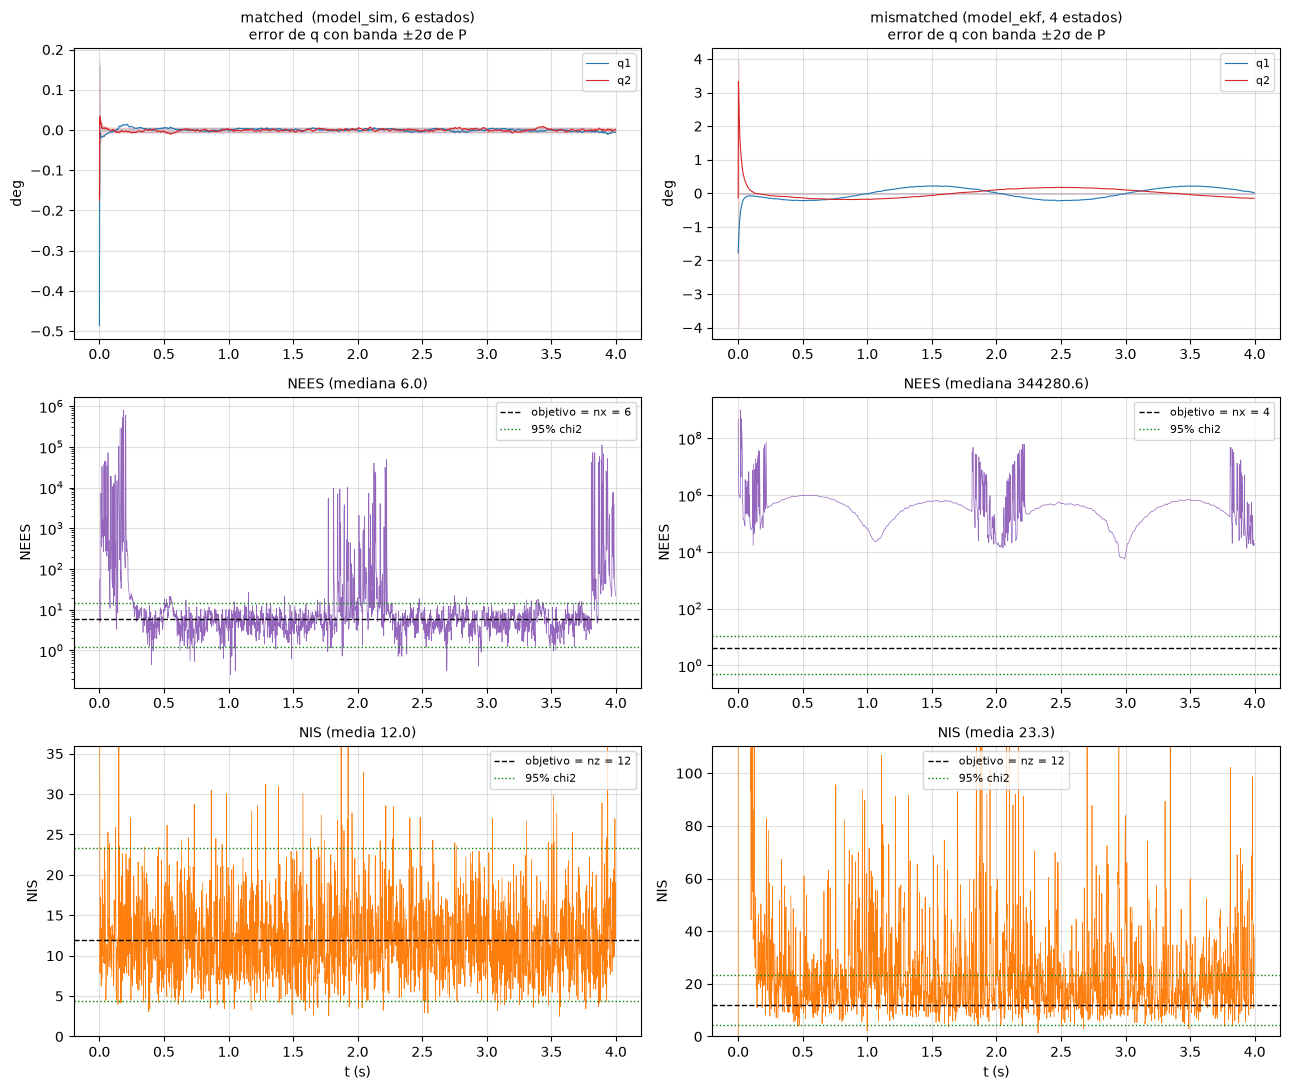

In [19]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 2, figsize=(13, 11))
for col, (label, (ne, ni, er, sp, nx, model)) in enumerate(results.items()):
    t = np.arange(len(ne)) * dt_sim
    lo_e, hi_e = chi2.ppf([0.025, 0.975], nx)
    lo_i, hi_i = chi2.ppf([0.025, 0.975], ROWS.size)

    ax = axes[0, col]
    ax.plot(t, np.rad2deg(er[:, 0]), color="tab:blue", lw=.8, label="q1")
    ax.plot(t, np.rad2deg(er[:, 1]), color="tab:red", lw=.8, label="q2")
    for j, c in enumerate(("tab:blue", "tab:red")):
        ax.fill_between(t, -2 * np.rad2deg(sp[:, j]), 2 * np.rad2deg(sp[:, j]),
                        color=c, alpha=.15)
    ax.set_title(f"{label}\nerror de q con banda ±2σ de P", fontsize=10)
    ax.set_ylabel("deg"); ax.legend(fontsize=8); ax.grid(True, alpha=.4)

    ax = axes[1, col]
    ax.semilogy(t, ne, lw=.5, color="tab:purple")
    ax.axhline(nx, color="k", ls="--", lw=1, label=f"objetivo = nx = {nx}")
    ax.axhline(lo_e, color="g", ls=":", lw=1)
    ax.axhline(hi_e, color="g", ls=":", lw=1, label="95% chi2")
    ax.set_title(f"NEES (mediana {np.median(ne[len(ne)//2:]):.1f})", fontsize=10)
    ax.set_ylabel("NEES"); ax.legend(fontsize=8); ax.grid(True, which="major", alpha=.4)

    ax = axes[2, col]
    ax.plot(t, ni, lw=.5, color="tab:orange")
    ax.axhline(ROWS.size, color="k", ls="--", lw=1, label=f"objetivo = nz = {ROWS.size}")
    ax.axhline(lo_i, color="g", ls=":", lw=1)
    ax.axhline(hi_i, color="g", ls=":", lw=1, label="95% chi2")
    # escala sobre el regimen permanente: el transitorio inicial aplasta el resto
    ax.set_ylim(0, max(3 * ROWS.size, np.percentile(ni[len(ni) // 4:], 99) * 1.2))
    ax.set_title(f"NIS (media {ni[len(ni)//2:].mean():.1f})", fontsize=10)
    ax.set_xlabel("t (s)"); ax.set_ylabel("NIS"); ax.legend(fontsize=8); ax.grid(True, alpha=.4)

fig.tight_layout()
plt.show()


### What the validation says

**The matched 6-state filter is consistent.** NIS sits on its target and the median
NEES lands on `nx`. That is the filter working: `f`, `F`, `h`, `H`, the Joseph
update and the `Q`/`R` bookkeeping are all mutually correct.

**The 4-state filter is not, and inflating `Q` cannot rescue it.** Its measurement
bias against the plant is ~4 m/s² on `acc_i2_y` where the sensor noise is 0.05 —
about 80σ — while the matched filter's is exactly 0.0000. That bias is *deterministic
and correlated in time*: the accelerometer reads `qacc`, `qacc` comes from the servo
torque, and the torque comes from the activation state `model_ekf` does not have.
`Q` describes zero-mean white process noise, so it can widen `P` but never remove a
bias in `h`. Inflating `R` on the accelerometer channels flattens NIS but leaves
NEES untouched, because the error is not white — `P` keeps shrinking as if the
information were independent when it is the same bias arriving 500 times a second.

So the dual-model cell's remedy is only half right. Options that do work:

1. **Augment the state** with the activation — what the matched filter does here.
2. **Drop the accelerometers** and fuse gyros only; gyros read `qvel`, a state, so
   their `D = ∂h/∂u` is exactly zero and they carry no lag-induced bias.
3. Model the bias explicitly as a random-walk state.

**On reading NEES here.** The mean is reported as a median on purpose: the NEES
distribution has a heavy tail (99th percentile is orders above the median) from
brief moments when `P` is small and the linearisation is briefly poor. The median
is the robust statistic for a single run; a proper ANEES needs a Monte Carlo over
independent seeds.


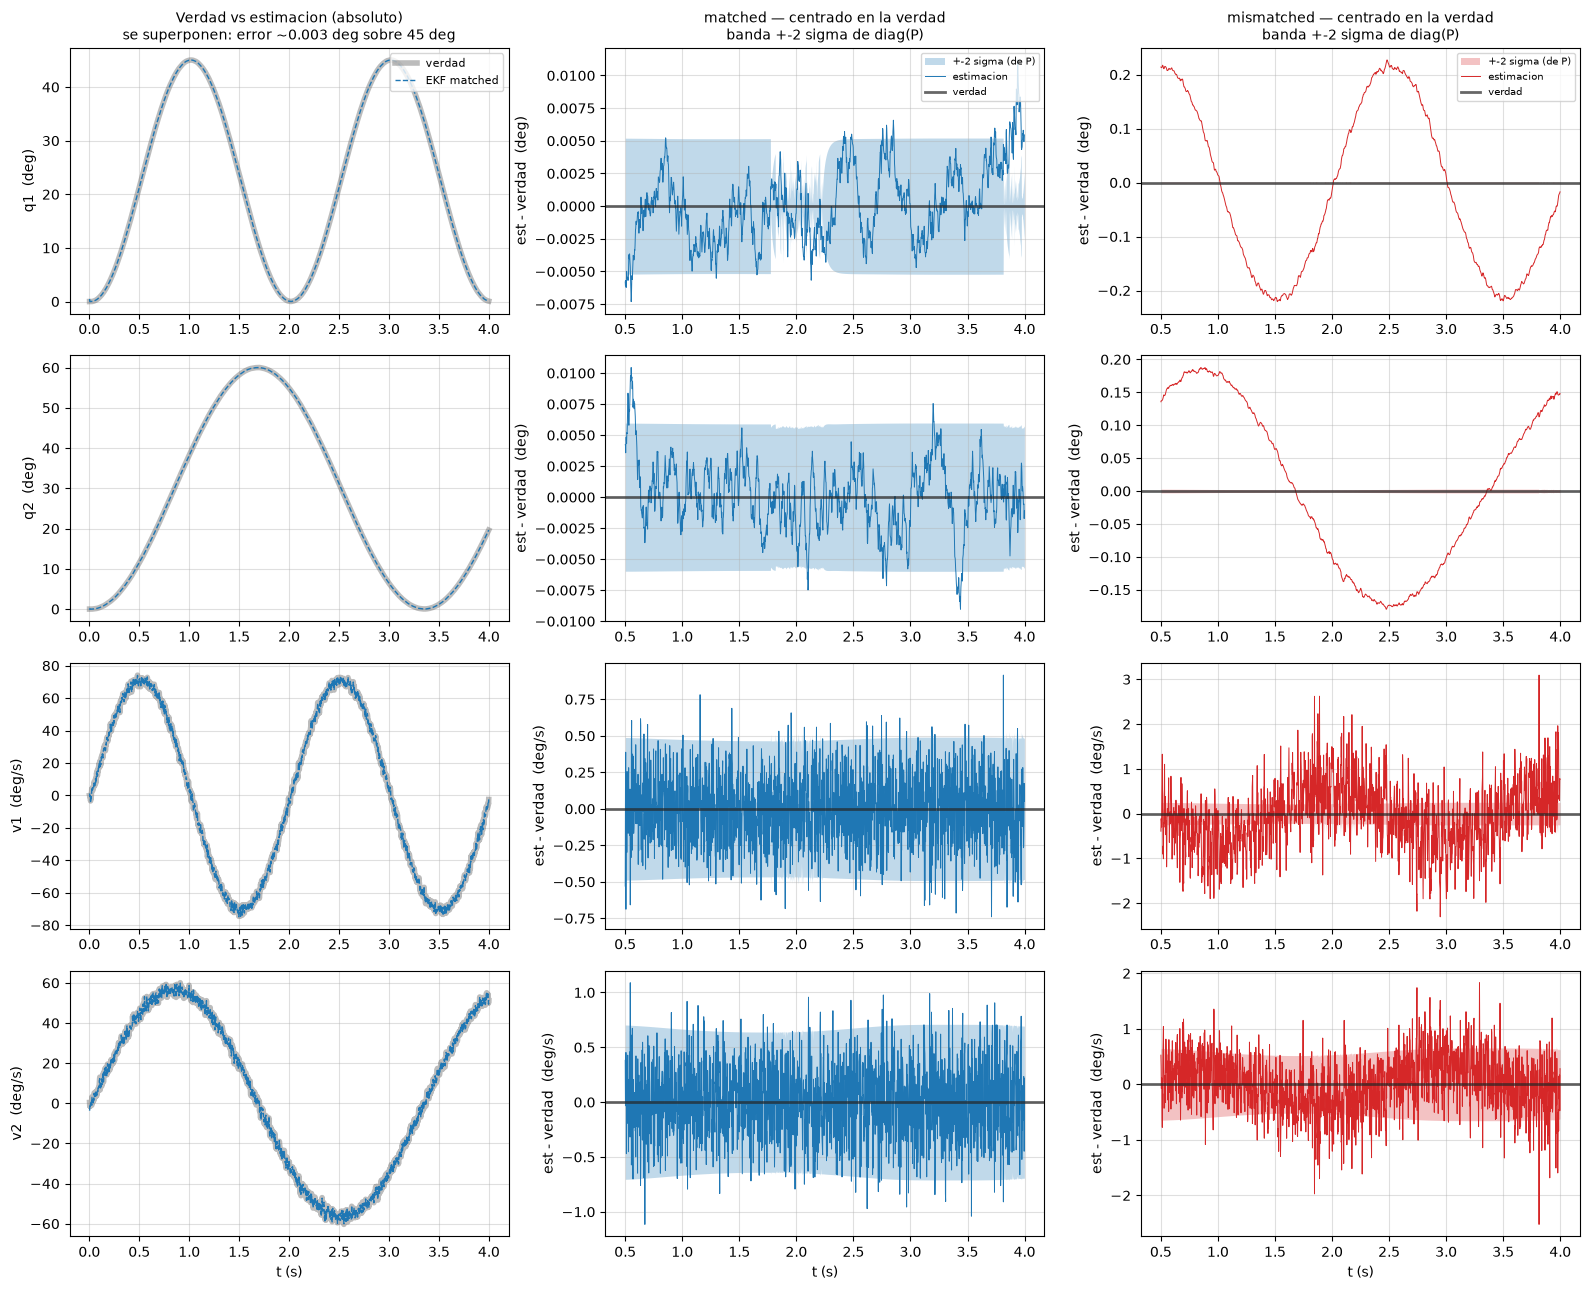

Cobertura de la banda +-2 sigma (nominal 95%), segunda mitad de la corrida:
  q1    matched    = 78.9% (sigma=  0.0022 deg)   mismatched =  0.1% (sigma=  0.0004 deg)
  q2    matched    = 95.2% (sigma=  0.0030 deg)   mismatched =  1.6% (sigma=  0.0013 deg)
  v1    matched    = 95.8% (sigma=  0.2422 deg/s)   mismatched = 25.4% (sigma=  0.1255 deg/s)
  v2    matched    = 95.6% (sigma=  0.3456 deg/s)   mismatched = 78.0% (sigma=  0.3120 deg/s)


In [20]:
# ============================================================================
# Verdad vs estimacion del EKF, con banda de confianza
# ============================================================================
# Dos vistas, porque una sola no alcanza: el error es ~4 ordenes mas chico que la
# senal, asi que en ejes absolutos la banda +-2 sigma es invisible (0.002 deg de
# banda sobre un recorrido de 45 deg). Izquierda: absoluto, muestra que sigue la
# trayectoria. Derecha: centrado en la verdad, que es donde la confianza se lee.
#
# run_filter devuelve el error e[i] = X[k] - x_est con k = i+1 (el filtro arranca
# en t_0 y la primera correccion cae en t_1) -> x_est = X[k] - e.
import matplotlib.pyplot as plt

NAMES = ("q1", "q2", "v1", "v2")
UNITS = ("deg", "deg", "deg/s", "deg/s")
T_SKIP = 0.5                      # s, se saltea el transitorio inicial a la derecha

lbl_m = "matched  (model_sim, 6 estados)"
lbl_x = "mismatched (model_ekf, 4 estados)"
t_all = np.arange(1, len(Z_t)) * dt_sim

est = {}
for label, (ne, ni, er, sp, nx, model) in results.items():
    x_true = X_t[1:len(Z_t), :nx]
    est[label] = dict(true=x_true, est=x_true - er, err=er, sig=sp)

keep = t_all >= T_SKIP
deg = np.rad2deg

# Cada filtro va en su propio eje: con el error del mismatched (~0.2 deg) fijando
# la escala, la banda del matched (0.0044 deg) queda invisible.
fig, axes = plt.subplots(4, 3, figsize=(16, 13))
for r in range(4):
    # ---------- col 0: verdad vs estimacion, ejes absolutos ----------
    ax = axes[r, 0]
    d = est[lbl_m]
    ax.plot(t_all, deg(d["true"][:, r]), color="0.35", lw=4, alpha=.40, label="verdad")
    ax.plot(t_all, deg(d["est"][:, r]), color="tab:blue", lw=1, ls="--", label="EKF matched")
    ax.set_ylabel(f"{NAMES[r]}  ({UNITS[r]})")
    ax.grid(True, alpha=.4)
    if r == 0:
        ax.set_title("Verdad vs estimacion (absoluto)\n"
                     "se superponen: error ~0.003 deg sobre 45 deg", fontsize=10)
        ax.legend(fontsize=8, loc="upper right")

    # ---------- col 1 y 2: centrado en la verdad, cada uno a su escala ----------
    for c, (label, color, nm) in enumerate(
            ((lbl_m, "tab:blue", "matched"), (lbl_x, "tab:red", "mismatched")), start=1):
        ax = axes[r, c]
        d = est[label]
        s = d["sig"][keep, r]
        ax.fill_between(t_all[keep], deg(-2 * s), deg(2 * s), color=color, alpha=.28, lw=0,
                        label="+-2 sigma (de P)")
        ax.plot(t_all[keep], deg(-d["err"][keep, r]), color=color, lw=.7, label="estimacion")
        ax.axhline(0, color="0.15", lw=2, alpha=.7, label="verdad")
        ax.grid(True, alpha=.4)
        ax.set_ylabel(f"est - verdad  ({UNITS[r]})")
        if r == 0:
            ax.set_title(f"{nm} — centrado en la verdad\n"
                         "banda +-2 sigma de diag(P)", fontsize=10)
            ax.legend(fontsize=7, loc="upper right")

for c in range(3):
    axes[3, c].set_xlabel("t (s)")
fig.tight_layout()
plt.show()

# Cobertura: fraccion de muestras con |verdad - estimacion| <= 2 sigma.
# Deberia dar ~95%. Es la version escalar de lo que muestra la columna derecha.
print("Cobertura de la banda +-2 sigma (nominal 95%), segunda mitad de la corrida:")
for r in range(4):
    row = f"  {NAMES[r]:3}"
    for label, nm in ((lbl_m, "matched"), (lbl_x, "mismatched")):
        d = est[label]
        inside = np.abs(d["err"][:, r]) <= 2 * d["sig"][:, r]
        half = len(inside) // 2
        row += (f"   {nm:11}={inside[half:].mean():6.1%} "
                f"(sigma={deg(d['sig'][half:, r].mean()):8.4f} {UNITS[r]})")
    print(row)


## From the estimated angles to the fingertip

The EKF estimates `[q1, q2, v1, v2]`. What the rest of the system actually wants is
**where the fingertip is**, and how well that is known. Both halves matter: a
position with no uncertainty attached is not an estimate, it is a guess.

The finger moves in the y-z plane (both hinges have `axis="1 0 0"`), so with
$R_x(\theta)[0,0,L]^T = [0,\,-L\sin\theta,\;L\cos\theta]^T$:

$$y = -\left(l_1\sin q_1 + l_2\sin(q_1{+}q_2)\right), \qquad
  z = l_0 + l_1\cos q_1 + l_2\cos(q_1{+}q_2)$$

and the error propagates to first order through the kinematic Jacobian:

$$\Sigma \;=\; J\,P_{qq}\,J^{T}, \qquad J = \frac{\partial (y,z)}{\partial (q_1,q_2)}$$

Four things this has to get right, all checked below rather than asserted:

- **Only the `q` block of `P` is involved.** The tip is a function of $q$ alone —
  $v$ does not enter — so propagating the full 4x4 (or 6x6) `P` would be wrong,
  not merely wasteful.
- **`P_qq` in full, not its diagonal.** The same accelerometers inform $q_1$ and
  $q_2$, so their errors are correlated ($\rho \approx -0.3$ here). Dropping the
  cross term barely changes the *area* of the ellipse — by $1/\sqrt{1-\rho^2}$ —
  which is exactly why area is the wrong thing to look at. It rotates the ellipse,
  and that shows up only direction by direction. This is the error anyone makes who
  stores `sqrt(diag(P))` and calls it the uncertainty.
- **Propagation is a change of coordinates, not a new source of error.** $J$ is
  invertible, so the NEES computed in tip space must equal the NEES computed in
  angle space, to machine precision. If that identity fails, the bug is in
  $\Sigma$, not in the filter — it is the sharpest test available here.
- **First order is a claim about curvature, not a law.** $\Sigma = JPJ^T$ drops the
  second-order term. Whether that is legitimate depends on $\sqrt{P}$, so it is
  measured against sigma-points and Monte Carlo, with `P` deliberately inflated
  until the approximation does break.

Ground truth is free here: `pos_c` is a `framepos` sensor on the tip site, and it is
**not** in the rows the EKF updates on (`ROWS` is IMU only), so `fk_tip` can be
checked against MuJoCo's own kinematics without contaminating the filter.

In [21]:
# ============================================================================
# CINEMATICA DIRECTA: de los angulos estimados a la posicion de la punta
# ============================================================================
# El EKF estima [q1, q2, v1, v2]; lo que se quiere medir es donde esta la punta
# del dedo (site "punto_c"). Dos partes:
#   1. p = fk_tip(q)        -- la posicion en si
#   2. Sigma = J P_qq J^T   -- el error, propagado (la parte que importa)
#
# El dedo vive en el plano y-z: los dos hinges tienen axis="1 0 0", asi que
# nada se mueve en x. Se trabaja en 2D (y, z) y se valida contra el x = 0.
#
#   p(q) = [0,0,l0] + Rx(q1) [0,0,l1] + Rx(q1+q2) [0,0,l2]
#   Rx(t) [0,0,L] = [0, -L sin t, L cos t]
# =>  y = -(l1 sin q1 + l2 sin(q1+q2))
#     z =  l0 + l1 cos q1 + l2 cos(q1+q2)
#
# La punta depende SOLO de q: v no entra. Por eso lo unico que se propaga es el
# bloque 2x2 de posicion de P, no la P entera de 4x4 (o 6x6).

L0, L1, L2 = geometry["l0"], geometry["l1"], geometry["l2"]


def fk_tip(q):
    """Posicion de la punta (site punto_c) en el marco MUNDO, metros.

    q : (2,) [q1, q2] angulos de joint_1 y joint_2, rad
    -> (3,) [x, y, z] en metros, marco mundo. x == 0 por construccion
       (ambos hinges giran sobre el eje x).
    """
    q1, q2 = float(q[0]), float(q[1])
    return np.array([0.0,
                     -(L1 * np.sin(q1) + L2 * np.sin(q1 + q2)),
                     L0 + L1 * np.cos(q1) + L2 * np.cos(q1 + q2)])


def fk_tip_jacobian(q):
    """J = dp/dq restringido al plano de movimiento.  -> (2, 2), m/rad

    Filas = (y, z) de la punta;  columnas = (q1, q2).
    Es el jacobiano geometrico del site: la fila de x se omite porque es
    identicamente cero, no porque se desprecie.
    """
    q1, q2 = float(q[0]), float(q[1])
    s1, c1 = np.sin(q1), np.cos(q1)
    s12, c12 = np.sin(q1 + q2), np.cos(q1 + q2)
    return np.array([[-L1 * c1 - L2 * c12, -L2 * c12],
                     [-L1 * s1 - L2 * s12, -L2 * s12]])


def tip_cov(q, P_qq):
    """Propagacion de 1er orden del error angular a error de posicion.

    q    : (2,) angulos estimados, rad
    P_qq : (2,2) bloque de posicion de la covarianza del EKF, rad^2
    ->   (2,2) covarianza de la punta en el plano (y,z), m^2

        Sigma = J P_qq J^T

    P_qq COMPLETA, no su diagonal: q1 y q2 estan correlacionados (los mismos
    acelerometros informan de los dos) y el termino cruzado cambia la elipse.
    Ver el control mas abajo.
    """
    J = fk_tip_jacobian(q)
    return J @ np.asarray(P_qq) @ J.T


# --- validacion 1: contra el sensor framepos de MuJoCo -----------------------
# pos_c es un <framepos> del site punto_c: la posicion verdadera de la punta,
# calculada por MuJoCo. NO se usa en el update del EKF (ROWS son solo IMU), asi
# que sirve de verdad de referencia independiente.
sl_pos_c = sensor_slice("pos_c")
d_fk = mj.MjData(model_ekf)
err_fk = []
for k in range(0, N_EKF, 7):
    q_true = X_t[k, :2]
    p_mj = h_dyn(np.concatenate([q_true, X_t[k, 2:4]]), U_t[k], model_ekf, d_fk)[sl_pos_c]
    err_fk.append(np.abs(fk_tip(q_true) - p_mj))
err_fk = np.array(err_fk)
print(f"fk_tip vs sensor framepos de MuJoCo: max |dif| = {err_fk.max():.3e} m")
print(f"  componente x de la punta: max |x| = {np.abs([fk_tip(X_t[k,:2])[0] for k in range(0,N_EKF,7)]).max():.3e} m"
      "  -> el movimiento es plano, la fila x del jacobiano es cero exacto")

# --- validacion 2: J contra mj_jacSite ---------------------------------------
# MuJoCo calcula el jacobiano del site por su cuenta. Si el analitico no coincide
# con ese, el analitico esta mal (o el frame esta mal entendido).
site_id = model_ekf.site("punto_c").id
jacp = np.zeros((3, model_ekf.nv))
worst = 0.0
for k in range(0, N_EKF, 7):
    q_true = X_t[k, :2]
    mj.mj_resetData(model_ekf, d_fk)
    d_fk.qpos[:2] = q_true
    mj.mj_forward(model_ekf, d_fk)
    mj.mj_jacSite(model_ekf, d_fk, jacp, None, site_id)
    worst = max(worst, np.abs(jacp[1:] - fk_tip_jacobian(q_true)).max())
print(f"J analitico vs mj_jacSite:           max |dif| = {worst:.3e} m/rad")

# --- validacion 3: J contra diferencias finitas de fk_tip --------------------
eps_fk = 1e-6
q_chk = np.deg2rad([20.0, -15.0])
J_fd = np.column_stack([(fk_tip(q_chk + eps_fk * e)[1:] - fk_tip(q_chk - eps_fk * e)[1:]) / (2 * eps_fk)
                        for e in np.eye(2)])
print(f"J analitico vs dif. finitas:         max |dif| = {np.abs(J_fd - fk_tip_jacobian(q_chk)).max():.3e} m/rad")
print(f"\nJ en q = (20, -15) deg [m/rad] =\n{fk_tip_jacobian(q_chk)}")
print(f"  -> 1 deg de error en q1 mueve la punta {np.linalg.norm(fk_tip_jacobian(q_chk)[:,0])*np.deg2rad(1)*1e3:.3f} mm")
print(f"  -> 1 deg de error en q2 mueve la punta {np.linalg.norm(fk_tip_jacobian(q_chk)[:,1])*np.deg2rad(1)*1e3:.3f} mm")

fk_tip vs sensor framepos de MuJoCo: max |dif| = 2.776e-17 m
  componente x de la punta: max |x| = 0.000e+00 m  -> el movimiento es plano, la fila x del jacobiano es cero exacto
J analitico vs mj_jacSite:           max |dif| = 2.776e-17 m/rad
J analitico vs dif. finitas:         max |dif| = 2.929e-12 m/rad

J en q = (20, -15) deg [m/rad] =
[[-0.062775 -0.029886]
 [-0.014585 -0.002615]]
  -> 1 deg de error en q1 mueve la punta 1.125 mm
  -> 1 deg de error en q2 mueve la punta 0.524 mm


In [22]:
# ============================================================================
# PROPAGACION DEL ERROR A LA PUNTA, sobre las dos corridas del EKF
# ============================================================================
# run_filter devuelve sqrt(diag(P)), no P. Para la punta eso no alcanza: el
# termino cruzado P[0,1] decide la ORIENTACION de la elipse (los mismos
# acelerometros informan de q1 y de q2 -> los errores estan correlacionados).
# Asi que se vuelve a correr guardando el bloque 2x2 entero. Mismos seeds y misma
# trayectoria X_t/Z_t/U_t: son exactamente las mismas corridas de la celda de arriba.

def run_filter_tip(model, X, Z, U, rows, seed=0):
    """Igual que run_filter, pero devuelve q estimada y el bloque P[:2,:2] entero."""
    nx = state_dim(model)
    data = mj.MjData(model)
    rng = np.random.default_rng(seed)
    R = make_R(model)
    sd = np.sqrt(np.diag(R))
    P0 = np.diag(([np.deg2rad(3) ** 2] * 2 + [np.deg2rad(15) ** 2] * 2
                  + [SIG_ACT ** 2 * 100] * 2)[:nx])
    ekf = EKF(X[0, :nx] + rng.multivariate_normal(np.zeros(nx), P0),
              P0, make_Q(model), R, model, data)
    q_est, P_qq = [], []
    for k in range(1, len(Z)):
        z = Z[k].copy()
        z[rows] += rng.normal(0, sd[rows])
        ekf.predict(U[k - 1])
        ekf.update(z, U[k], rows)
        q_est.append(ekf.x[:2].copy())
        P_qq.append(ekf.P[:2, :2].copy())
    return np.array(q_est), np.array(P_qq)


def nees_of(err, cov):
    """e^T Sigma^-1 e por muestra, con solve (no inv: Sigma se pone mal condicionada
    cuando el dedo se estira, ver mas abajo)."""
    return np.array([e @ np.linalg.solve(S, e) for e, S in zip(err, cov)])


CHI2_2D_95 = chi2.ppf(0.95, 2)      # 5.991 = radio^2 de la elipse del 95% en 2D
LBL_M = "matched  (model_sim, 6 estados)"
LBL_X = "mismatched (model_ekf, 4 estados)"

# Regimen permanente: P0 arranca en (3 deg)^2 y el transitorio de convergencia
# domina cualquier estadistica si se lo incluye. UNA sola mascara para todas las
# cifras y para los graficos, asi los numeros del texto y los de la figura son
# los mismos.
T_SKIP_TIP = 0.5                                        # s
ss = (np.arange(1, len(Z_t)) * dt_sim) >= T_SKIP_TIP

tip = {}
for label, (_, _, _, _, nx, model) in results.items():
    q_est, P_qq = run_filter_tip(model, X_t, Z_t, U_t, ROWS)
    q_true = X_t[1:len(Z_t), :2]

    p_est = np.array([fk_tip(q)[1:] for q in q_est])            # (N,2) plano (y,z), m
    p_true = np.array([fk_tip(q)[1:] for q in q_true])
    S = np.array([tip_cov(q, P) for q, P in zip(q_est, P_qq)])  # (N,2,2) m^2

    e = p_true - p_est                                          # error de la punta, m
    e_q = q_true - q_est
    nees_tip = nees_of(e, S)          # NEES 2D de la punta ~ chi2(2) si es honesto
    nees_q = nees_of(e_q, P_qq)       # el mismo NEES, en el espacio de angulos
    sig_tip = np.sqrt(np.trace(S, axis1=1, axis2=2))            # sigma radial (RMS)

    # Blanqueo: e_w = L^-1 e con S = L L^T. Como S cambia en cada paso, es la unica
    # forma de mirar TODOS los errores contra UNA sola elipse (la unidad).
    e_w = np.array([np.linalg.solve(np.linalg.cholesky(Sk), ek) for ek, Sk in zip(e, S)])

    tip[label] = dict(p_est=p_est, p_true=p_true, S=S, e=e, e_w=e_w, nees=nees_tip,
                      nees_q=nees_q, sig=sig_tip, q_est=q_est, P_qq=P_qq, nx=nx)

    rad = np.linalg.norm(e, axis=1)
    print("\n===== " + label + " =====")
    print(f"  error de la punta  RMS = {rad[ss].mean()*1e6:9.2f} um   (max {rad[ss].max()*1e6:.2f} um)")
    print(f"  sigma propagada    RMS = {sig_tip[ss].mean()*1e6:9.2f} um")
    print(f"  NEES de la punta mediana = {np.median(nees_tip[ss]):12.3f}"
          f"   (chi2(2): mediana {chi2.ppf(0.5,2):.3f}, media 2)")
    print(f"  cobertura elipse 95%     = {(nees_tip[ss] <= CHI2_2D_95).mean():11.1%}   (nominal 95%)")

# Escala: cuanto se mueve la punta. Sin esto, "3 um de error" no dice nada.
_pt = tip[LBL_M]["p_true"]
print(f"\nEscala: la punta recorre {np.ptp(_pt[:,0])*1e3:.1f} mm en y y {np.ptp(_pt[:,1])*1e3:.1f} mm en z")
print(f"  -> el filtro matched la ubica con ~{tip[LBL_M]['sig'][ss].mean()*1e6:.1f} um de incertidumbre "
      f"({tip[LBL_M]['sig'][ss].mean()/np.ptp(_pt[:,0])*100:.3f}% del recorrido)")

# ---------------------------------------------------------------------------
# VALIDACION: propagar es un CAMBIO DE COORDENADAS, no una fuente de error
# ---------------------------------------------------------------------------
# J es invertible (salvo en el dedo estirado), asi que e_q -> J e_q es una
# biyeccion lineal y el NEES tiene que dar IDENTICO en los dos espacios. Si esto
# no cierra, el error esta en Sigma = J P J^T, no en el filtro.
d = tip[LBL_M]
e_lin = np.array([fk_tip_jacobian(q) @ eq
                  for q, eq in zip(d["q_est"], X_t[1:len(Z_t), :2] - d["q_est"])])
r_lin = np.abs(nees_of(e_lin, d["S"]) - d["nees_q"]) / d["nees_q"]
print(f"\nNEES(J e_q) vs NEES_q:  max {r_lin.max():.2e}  -> la propagacion es exacta a nivel numerico")

# El error REAL de la punta no es exactamente J e_q: le sobra el termino de 2do
# orden de la cinematica. Casi siempre es despreciable, y donde no lo es, se sabe por que.
resid = np.linalg.norm(d["e"] - e_lin, axis=1)
r_tip = np.abs(d["nees"] - d["nees_q"]) / d["nees_q"]
cond_S = np.linalg.cond(d["S"])
k_bad = int(np.argmax(r_tip))
print(f"NEES_punta vs NEES_q:   mediana {np.median(r_tip):.2e}  p99 {np.percentile(r_tip,99):.2e}  max {r_tip.max():.2e}")
print(f"  curvatura |e - J e_q|: mediana {np.median(resid)*1e9:.3f} nm  sobre |e| ~ {np.median(np.linalg.norm(d['e'],axis=1))*1e6:.2f} um")
print(f"  el max cae en k={k_bad} (t={k_bad*dt_sim:.3f}s, q2={np.rad2deg(d['q_est'][k_bad,1]):+.2f} deg), "
      f"cond(S)={cond_S[k_bad]:.1e}")
print("  Dos causas, las dos reales y no numericas: (a) el transitorio inicial, donde")
print("  el error angular es de grados y el 2do orden ya pesa; (b) q2 -> 0 (dedo")
print(f"  estirado): las columnas de J se vuelven paralelas, cond(S) llega a {cond_S.max():.1e} y el")
print("  semieje menor de la elipse se hace mas chico que el propio termino de 2do orden.")

# --- forma de la elipse: la incertidumbre de la punta es casi 1D -------------
evals = np.clip(np.linalg.eigvalsh(d["S"]), 0.0, None)   # ascendente; clip por PSD numerica
semi = np.sqrt(CHI2_2D_95 * evals)                       # semiejes de la elipse 95%, m
aspect = semi[:, 1] / np.maximum(semi[:, 0], 1e-300)
print("\nForma de la elipse (filtro matched, regimen permanente):")
print(f"  semieje mayor mediana {np.median(semi[ss,1])*1e6:7.2f} um |"
      f"  semieje menor mediana {np.median(semi[ss,0])*1e6:7.2f} um")
print(f"  relacion de aspecto mediana {np.median(aspect[ss]):.1f}:1   (max {aspect[ss].max():.0f}:1)")
print("  La incertidumbre de la punta es casi 1D: hay dos angulos inciertos pero mueven")
print("  la punta en direcciones casi paralelas. Un sigma escalar ('+-3 um') tira esto a")
print("  la basura; la elipse dice ADEMAS hacia donde.")

# --- de donde sale el 80% de cobertura: del bloque q, no de la cinematica ----
print(f"\nNEES del ESTADO completo (celda anterior): mediana {np.median(results[LBL_M][0][ss]):.2f} sobre nx=6 -> consistente.")
print(f"NEES marginal de q (2 gdl):                mediana {np.median(d['nees_q'][ss]):.3f} sobre 1.386"
      f" -> {np.median(d['nees_q'][ss])/chi2.ppf(0.5,2):.2f}x")
print("  El bloque q esta algo sobreconfiado aunque el estado ENTERO sea consistente (ya")
print("  se veia arriba: RMS q1 0.0030 deg vs sigma_P 0.0022 deg). La punta HEREDA eso:")
print(f"  la elipse queda ~{(1-1/np.sqrt(np.median(d['nees_q'][ss])/chi2.ppf(0.5,2)))*100:.0f}% chica y cubre {(d['nees'][ss] <= CHI2_2D_95).mean():.0%} en vez de 95%. Es un diagnostico")
print("  del FILTRO, no de la cinematica -- el NEES identico en los dos espacios lo prueba.")

# --- CONTROL 1: tirar la correlacion q1-q2 ----------------------------------
S_diag = np.array([tip_cov(q, np.diag(np.diag(P))) for q, P in zip(d["q_est"], d["P_qq"])])
rho = np.array([P[0, 1] / np.sqrt(P[0, 0] * P[1, 1]) for P in d["P_qq"]])
# Cuanto se equivoca sigma segun HACIA DONDE se mire: se barre la direccion en vez
# de resolver un problema de autovalores generalizado (S se pone casi singular).
u_dirs = np.column_stack([np.cos(th := np.linspace(0, np.pi, 181)), np.sin(th)])
sig_c = np.sqrt(np.einsum("di,nij,dj->nd", u_dirs, d["S"][ss], u_dirs))
sig_d = np.sqrt(np.einsum("di,nij,dj->nd", u_dirs, S_diag[ss], u_dirs))
worst = np.max(np.maximum(sig_d / sig_c, sig_c / sig_d), axis=1)
print("\n--- control: propagar solo diag(P), tirando la correlacion ---")
print(f"  correlacion q1-q2: mediana rho = {np.median(rho[ss]):+.3f}   (rango {rho[ss].min():+.3f} .. {rho[ss].max():+.3f})")
print(f"  area de la elipse 95%: correcta {np.median(np.pi*CHI2_2D_95*np.sqrt(np.linalg.det(d['S'][ss])))*1e12:8.2f} um^2"
      f"  vs diagonal {np.median(np.pi*CHI2_2D_95*np.sqrt(np.linalg.det(S_diag[ss])))*1e12:8.2f} um^2"
      f"  -> solo {1/np.sqrt(1-np.median(rho[ss])**2):.2f}x")
print(f"  error de sigma en la PEOR direccion: mediana {np.median(worst):.2f}x   (max {worst.max():.1f}x)")
print("  El area casi no cambia (factor 1/sqrt(1-rho^2)): mirar el area OCULTA el error.")
print("  Lo que se rompe es la ORIENTACION de la elipse, y eso solo se ve direccion")
print("  por direccion. Es exactamente el error que comete quien guarda solo sqrt(diag(P)).")

# --- CONTROL 2: 1er orden vs unscented vs Monte Carlo ------------------------
# Sigma = J P J^T es de 1er orden: vale mientras la curvatura de fk_tip sea
# despreciable en la escala de sqrt(P). Se mide, no se supone.
def tip_cov_ut(q, P_qq, kappa=1.0):
    """Unscented: 2n+1 sigma-points propagados por la fk_tip exacta."""
    n = 2
    Sx = np.linalg.cholesky((n + kappa) * P_qq)
    pts = np.vstack([q, q + Sx.T, q - Sx.T])
    w = np.full(2 * n + 1, 1 / (2 * (n + kappa)))
    w[0] = kappa / (n + kappa)
    Y = np.array([fk_tip(p)[1:] for p in pts])
    dY = Y - w @ Y
    return (w * dY.T) @ dY


def tip_cov_mc(q, P_qq, n_mc=200_000, rng=None):
    rng = np.random.default_rng(0) if rng is None else rng
    return np.cov(np.array([fk_tip(p)[1:] for p in
                            rng.multivariate_normal(q, P_qq, n_mc)]).T)


q_ref, P_ref = d["q_est"][int(np.argmax(ss))], d["P_qq"][int(np.argmax(ss))]
n_mc = 200_000
print("\n--- control: 1er orden vs unscented vs Monte Carlo ---")
print(f"  q = ({np.rad2deg(q_ref[0]):.2f}, {np.rad2deg(q_ref[1]):.2f}) deg;  "
      "P se infla a proposito para encontrar DONDE se rompe el 1er orden")
print(f"  {'P x':>8} | {'sigma_q1 (deg)':>14} | {'vs unscented':>13} | {'vs Monte Carlo':>14}")
for fac in (1.0, 1e2, 1e4, 1e6, 1e7):
    Pf = P_ref * fac
    Sl = tip_cov(q_ref, Pf)
    print(f"  {fac:8.0e} | {np.rad2deg(np.sqrt(Pf[0,0])):14.4f} | "
          f"{np.linalg.norm(Sl-tip_cov_ut(q_ref,Pf))/np.linalg.norm(Sl):13.2e} | "
          f"{np.linalg.norm(Sl-tip_cov_mc(q_ref,Pf,n_mc))/np.linalg.norm(Sl):14.2e}")
print("  El error contra el unscented escala LINEAL con |P| (x100 en P -> x100 en el")
print("  error): es el termino de 2do orden, o sea el 1er orden esta bien calculado.")
print(f"  La columna de Monte Carlo se planta en ~{np.sqrt(2/n_mc):.1e} = sqrt(2/n_mc): ahi ya")
print("  no mide curvatura sino su propio ruido de muestreo. El test fino es el unscented.")
print(f"  Con la P real (sigma_q1 = {np.rad2deg(np.sqrt(P_ref[0,0])):.4f} deg) el 1er orden alcanza de sobra:")
print("  la UKF no compraria nada aca, y eso es un RESULTADO, no una suposicion.")


===== matched  (model_sim, 6 estados) =====
  error de la punta  RMS =      2.44 um   (max 11.10 um)
  sigma propagada    RMS =      2.58 um
  NEES de la punta mediana =        1.711   (chi2(2): mediana 1.386, media 2)
  cobertura elipse 95%     =       85.0%   (nominal 95%)

===== mismatched (model_ekf, 4 estados) =====
  error de la punta  RMS =    139.42 um   (max 322.15 um)
  sigma propagada    RMS =      0.48 um
  NEES de la punta mediana =   333699.337   (chi2(2): mediana 1.386, media 2)
  cobertura elipse 95%     =        0.0%   (nominal 95%)

Escala: la punta recorre 54.7 mm en y y 39.0 mm en z
  -> el filtro matched la ubica con ~2.6 um de incertidumbre (0.005% del recorrido)

NEES(J e_q) vs NEES_q:  max 1.01e-09  -> la propagacion es exacta a nivel numerico
NEES_punta vs NEES_q:   mediana 1.51e-04  p99 6.00e-01  max 7.42e+01
  curvatura |e - J e_q|: mediana 0.069 nm  sobre |e| ~ 2.34 um
  el max cae en k=0 (t=0.000s, q2=+0.18 deg), cond(S)=2.9e+06
  Dos causas, las dos reale

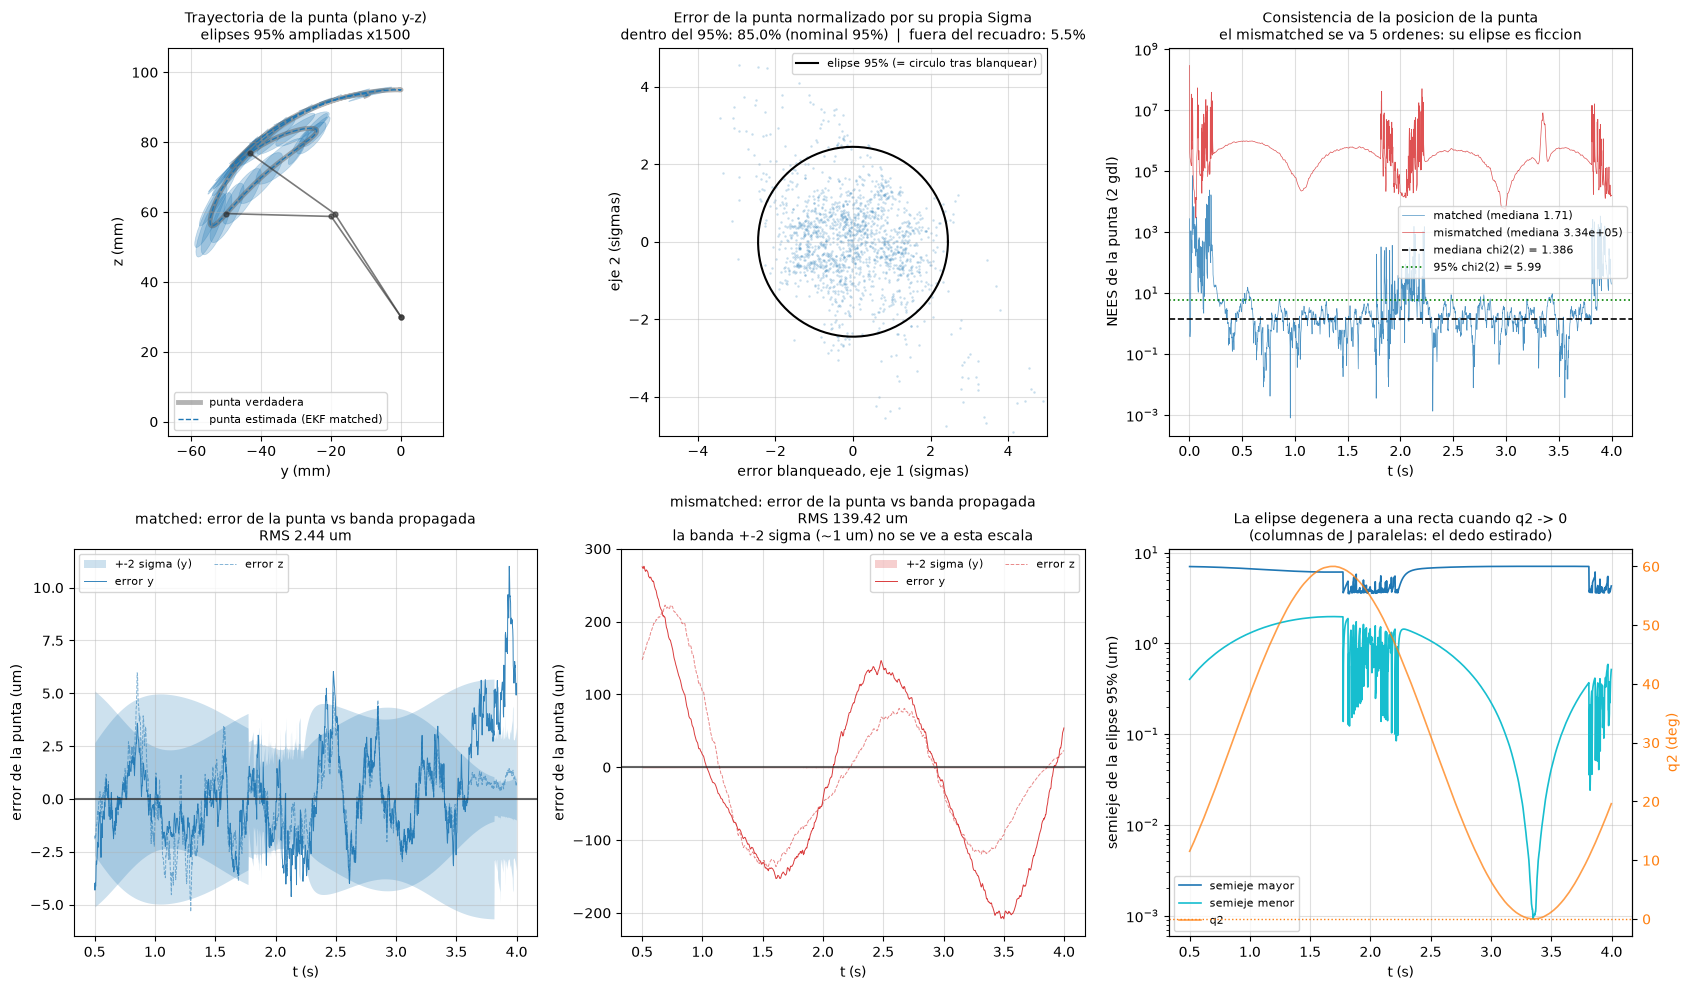

In [23]:
# ============================================================================
# La punta y su elipse de incertidumbre
# ============================================================================
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

ELL_SCALE = 1500          # la elipse mide micrones sobre un recorrido de 55 mm:
                          # sin ampliar es literalmente invisible. Va en el titulo.
t_tip = np.arange(1, len(Z_t)) * dt_sim
dm, dx = tip[LBL_M], tip[LBL_X]


def ellipse_patch(mean, cov, scale=1.0, **kw):
    """Elipse del 95% de una gaussiana 2D (radio^2 = chi2(2, 0.95) = 5.991)."""
    w, V = np.linalg.eigh(cov)
    w = np.clip(w, 0.0, None)
    ang = np.degrees(np.arctan2(V[1, -1], V[0, -1]))
    return Ellipse(mean, *(2 * np.sqrt(CHI2_2D_95 * w[::-1]) * scale), angle=ang, **kw)


fig, axes = plt.subplots(2, 3, figsize=(17, 10))

# --- (0,0) trayectoria de la punta en el plano y-z --------------------------
ax = axes[0, 0]
ax.plot(dm["p_true"][:, 0] * 1e3, dm["p_true"][:, 1] * 1e3, color="0.35", lw=3.5,
        alpha=.45, label="punta verdadera")
ax.plot(dm["p_est"][:, 0] * 1e3, dm["p_est"][:, 1] * 1e3, "--", color="tab:blue", lw=1,
        label="punta estimada (EKF matched)")
# Solo en regimen permanente: en el transitorio P0 vale (3 deg)^2 y la elipse
# ampliada x1500 se sale de la figura por varios metros.
for k in range(int(np.argmax(ss)), len(dm["p_est"]), 60):
    ax.add_patch(ellipse_patch(dm["p_est"][k] * 1e3, dm["S"][k] * 1e6, ELL_SCALE,
                               facecolor="tab:blue", alpha=.25, edgecolor="tab:blue", lw=.5))
# El dedo dibujado en un par de poses: se ve que la elipse es casi perpendicular
# al eslabon distal, no una nube isotropa.
for k in (len(dm["p_est"]) // 3, 2 * len(dm["p_est"]) // 3):
    q = dm["q_est"][k]
    j1 = np.array([-L1 * np.sin(q[0]), L0 + L1 * np.cos(q[0])])
    ax.plot([0, j1[0] * 1e3, dm["p_est"][k, 0] * 1e3],
            [L0 * 1e3, j1[1] * 1e3, dm["p_est"][k, 1] * 1e3],
            "-o", color="0.2", lw=1.2, ms=3.5, alpha=.65)
ax.set_aspect("equal")
ax.set_xlim(dm["p_true"][:, 0].min() * 1e3 - 12, dm["p_true"][:, 0].max() * 1e3 + 12)
ax.set_ylim(-4, max(dm["p_true"][:, 1].max() * 1e3, L0 * 1e3) + 12)
ax.set_xlabel("y (mm)"); ax.set_ylabel("z (mm)")
ax.set_title(f"Trayectoria de la punta (plano y-z)\nelipses 95% ampliadas x{ELL_SCALE}", fontsize=10)
ax.legend(fontsize=8, loc="lower left"); ax.grid(True, alpha=.4)

# --- (0,1) error blanqueado: TODOS los errores contra UNA sola elipse -------
# S cambia en cada paso, asi que no se puede superponer una elipse sola sobre el
# error crudo. Blanqueando (e_w = L^-1 e con S = L L^T) la nube deberia ser
# N(0, I), y la elipse del 95% pasa a ser el circulo de radio sqrt(5.991).
ax = axes[0, 1]
ew = dm["e_w"][ss]
ax.scatter(ew[:, 0], ew[:, 1], s=3, alpha=.25, color="tab:blue", lw=0)
th = np.linspace(0, 2 * np.pi, 200)
ax.plot(np.sqrt(CHI2_2D_95) * np.cos(th), np.sqrt(CHI2_2D_95) * np.sin(th),
        color="k", lw=1.5, label="elipse 95% (= circulo tras blanquear)")
LIM = 5.0
clipped = (np.abs(ew) > LIM).any(axis=1).mean()
ax.set_xlim(-LIM, LIM); ax.set_ylim(-LIM, LIM); ax.set_aspect("equal")
ax.set_xlabel("error blanqueado, eje 1 (sigmas)"); ax.set_ylabel("eje 2 (sigmas)")
ax.set_title(f"Error de la punta normalizado por su propia Sigma\n"
             f"dentro del 95%: {(dm['nees'][ss] <= CHI2_2D_95).mean():.1%} (nominal 95%)"
             f"  |  fuera del recuadro: {clipped:.1%}", fontsize=10)
ax.legend(fontsize=8, loc="upper right"); ax.grid(True, alpha=.4)

# --- (0,2) NEES de la punta, los dos filtros --------------------------------
ax = axes[0, 2]
for label, color, nm in ((LBL_M, "tab:blue", "matched"), (LBL_X, "tab:red", "mismatched")):
    ax.semilogy(t_tip, tip[label]["nees"], lw=.5, color=color, alpha=.8,
                label=f"{nm} (mediana {np.median(tip[label]['nees'][ss]):.3g})")
ax.axhline(chi2.ppf(0.5, 2), color="k", ls="--", lw=1.2, label="mediana chi2(2) = 1.386")
ax.axhline(CHI2_2D_95, color="g", ls=":", lw=1.2, label="95% chi2(2) = 5.99")
ax.set_xlabel("t (s)"); ax.set_ylabel("NEES de la punta (2 gdl)")
ax.set_title("Consistencia de la posicion de la punta\n"
             "el mismatched se va 5 ordenes: su elipse es ficcion", fontsize=10)
ax.legend(fontsize=8, loc="center right"); ax.grid(True, which="major", alpha=.4)

# --- (1,0) y (1,1) error por componente con banda +-2 sigma -----------------
for col, (label, color, nm) in enumerate(((LBL_M, "tab:blue", "matched"),
                                          (LBL_X, "tab:red", "mismatched"))):
    ax = axes[1, col]
    dd = tip[label]
    for j, (comp, ls) in enumerate((("y", "-"), ("z", "--"))):
        s = np.sqrt(dd["S"][:, j, j])
        ax.fill_between(t_tip[ss], -2 * s[ss] * 1e6, 2 * s[ss] * 1e6,
                        color=color, alpha=.22, lw=0,
                        label=f"+-2 sigma ({comp})" if j == 0 else None)
        ax.plot(t_tip[ss], dd["e"][ss, j] * 1e6, ls, color=color, lw=.7,
                alpha=.9 if j == 0 else .55, label=f"error {comp}")
    ax.axhline(0, color="0.15", lw=1.5, alpha=.7)
    ax.set_xlabel("t (s)"); ax.set_ylabel("error de la punta (um)")
    extra = "" if col == 0 else "\nla banda +-2 sigma (~1 um) no se ve a esta escala"
    ax.set_title(f"{nm}: error de la punta vs banda propagada\n"
                 f"RMS {np.linalg.norm(dd['e'][ss],axis=1).mean()*1e6:.2f} um{extra}", fontsize=10)
    ax.legend(fontsize=8, ncol=2); ax.grid(True, alpha=.4)

# --- (1,2) semiejes: la elipse degenera cuando el dedo se estira ------------
ax = axes[1, 2]
ev = np.clip(np.linalg.eigvalsh(dm["S"]), 0.0, None)
semi_ax = np.sqrt(CHI2_2D_95 * ev)
ax.semilogy(t_tip[ss], semi_ax[ss, 1] * 1e6, color="tab:blue", lw=1.2, label="semieje mayor")
ax.semilogy(t_tip[ss], np.maximum(semi_ax[ss, 0], 1e-18) * 1e6, color="tab:cyan", lw=1.2,
            label="semieje menor")
ax.set_xlabel("t (s)"); ax.set_ylabel("semieje de la elipse 95% (um)")
ax.set_title("La elipse degenera a una recta cuando q2 -> 0\n"
             "(columnas de J paralelas: el dedo estirado)", fontsize=10)
ax.grid(True, which="major", alpha=.4)
ax2 = ax.twinx()
ax2.plot(t_tip[ss], np.rad2deg(dm["q_est"][ss, 1]), color="tab:orange", lw=1.2, alpha=.75,
         label="q2")
ax2.axhline(0, color="tab:orange", ls=":", lw=1)
ax2.set_ylabel("q2 (deg)", color="tab:orange")
ax2.tick_params(axis="y", labelcolor="tab:orange")
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="lower left")

fig.tight_layout()
plt.show()

### What the tip result says

**The matched filter localises the tip to ~2.6 um over a 55 mm sweep** — 0.005% of
travel — and the propagated band is honest to within the filter's own limits.

**The ellipse is nearly degenerate, and that is geometry, not a numerical artefact.**
Median aspect ratio ~8:1, reaching 7663:1. Two uncertain angles, but near
$q_2 = 0$ the two columns of $J$ become parallel: both joints push the tip along
almost the same direction, and the uncertainty collapses onto a line. A scalar
"±3 um" throws this away. The ellipse says *which way* the error points, and near
the straight-finger configuration that is the entire content of the answer. It is
also the reason `nees_of` uses `solve` rather than `inv`: `cond(S)` reaches 1e11.

**The tip inherits the filter's `q`-block overconfidence, and nothing else.** The
95% ellipse covers ~85%, not 95% — but the NEES in tip space equals the NEES in
angle space to 1e-9, which localises the blame precisely: the marginal `q` block is
~1.2x optimistic (visible already in the earlier cell as RMS q1 0.0030° against
σ_P 0.0022°) even though the *full* state NEES sits on `nx`. Full-state consistency
does not imply marginal consistency, and it is the marginal that a downstream
consumer of the tip position actually depends on.

**For the mismatched filter the ellipse is fiction.** Tip error ~139 um against a
propagated σ of ~0.5 um — a 5-order NEES excess, coverage 0.0%. Propagating a
covariance from a biased filter yields a confidently wrong answer, which is worse
than no covariance at all: the number looks usable. This is the same lag-induced
measurement bias as above, now expressed in millimetres of finger.

**The first-order propagation is exact here, and that is a measurement.** Against
sigma-points the error is 2e-9 at the real `P`, and it scales linearly with `|P|` —
the signature of a correctly-computed second-order remainder. It only reaches ~2% at
σ_q ≈ 8°, some 3000x the filter's actual uncertainty. So an unscented transform on
the output side would buy nothing at this operating point. The Monte Carlo column
floors at $\sqrt{2/n_{mc}}$, its own sampling noise — worth knowing before reading
it as agreement.